### Exploration du contenu des mail

In [1]:
# Import des librairies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Embeddings
from sentence_transformers import SentenceTransformer

c:\Users\h-daniel.karamoko\Desktop\Admin\MS ENSAE\Cours\natural-language-processing\virtualenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Accès aux données et formattage
source = "data/apprentissage_interactions_2023_11.csv"
data = pd.read_csv(source, sep=";")
data["interaction_date"] = pd.to_datetime(data["interaction_date"])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 251793 entries, 0 to 251792
Data columns (total 11 columns):
 #   Column                                          Non-Null Count   Dtype         
---  ------                                          --------------   -----         
 0   client_code                                     251793 non-null  int64         
 1   interaction_motif                               251793 non-null  str           
 2   interaction_precision                           250792 non-null  str           
 3   interaction_canal                               251793 non-null  str           
 4   interaction_date                                251793 non-null  datetime64[us]
 5   interaction_service                             251793 non-null  str           
 6   interaction_est_transferee_service_reclamation  251793 non-null  int64         
 7   interaction_est_transferee_service_gestion      251793 non-null  int64         
 8   interaction_est_transferee_service_commercial

**Niveau d'analyse 1 : On reprends les mails de façon individuelle - granularité très fine**

In [3]:
# Récupération de la colonne de texte
pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_colwidth', 150)
df_email_level = data[data['interaction_canal']=='E-mail'][['client_code', 'interaction_date', 'interaction_texte_mail']]
df_email_level

,client_code,interaction_date,interaction_texte_mail
1,15029743,2022-12-09,xxpj0 xxobj TR: ALPTIS augmentation prime 2023 xxcont Accord pour 1 mois offert sur les adhésions : flag_client_ flag_client_ flag_clien...
3,14067838,2022-12-07,xxpj0 Scan_06122022163209 xxobj flag_client_ salies xxcont Ci-joint demande de remboursement.
9,14977635,2022-12-05,xxpj0 xxobj flag_localisation_ : flag_localisation_ flag_client_ flag_localisation_ flag_client_ xxcont Accord pour 1 mois offert : aba...
12,4423322,2022-12-28,xxpj0 DEVIS COLOSCOPIE flag_nom_ xxpj1 Descriptif Médico xxpj2 Notice Surcomplémentaire Hospi xxobj ADHERENT flag_client_ flag_nom_ xxcont ...
13,13281703,2022-12-12,"xxpj0 xxobj Résiliation contrat suite décès xxcont Bonjour, comme convenu, vous trouverez l'acte de décès de Mr flag_nom_ N° d'adhérent flag_..."
...,...,...,...
251783,15764092,2023-05-15,xxpj0 SCOP-33C-0023051511080 xxobj TR: Message from COP-33C-001 xxcont flag_client_ Carte ro + decompte + facture
251784,10174795,2023-06-05,xxpj0 doc08355820230531100513 xxobj Demande Remboursement - Adhésion n° flag_client_ flag_localisation_ - MALDONADO ADORACION. xxcont Vous t...
251790,14783147,2023-10-14,xxpj0 DEVIS MR flag_nom_ xxobj flag_client_ - DEVIS ESTIMATIF DENTAIRE AU NOM DE MONSIEUR flag_nom_ xxcont flag_client_ Je vous rem...
251791,15642691,2023-08-25,xxpj0 CamScanner 25- flag_phone_ xxobj CamScanner 25- flag_phone_ .pdf xxcont Ci-joint le devis pour mon opération de la cataracte de l'il dr...


In [5]:
# Extraction des composantes du mail
df_email_level['objet'] = df_email_level['interaction_texte_mail'].str.extract(r"(?is)xxobj\s+(?:(?:TR|RE|FW|FWD)\s*:\s*)?([\s\S]*?)(?:\s+xxcont|$)")
df_email_level['contenu'] = df_email_level['interaction_texte_mail'].str.extract(r"xxcont\s+(.*)$")
df_email_level

,client_code,interaction_date,interaction_texte_mail,objet,contenu
1,15029743,2022-12-09,xxpj0 xxobj TR: ALPTIS augmentation prime 2023 xxcont Accord pour 1 mois offert sur les adhésions : flag_client_ flag_client_ flag_clien...,ALPTIS augmentation prime 2023,Accord pour 1 mois offert sur les adhésions : flag_client_ flag_client_ flag_client_
3,14067838,2022-12-07,xxpj0 Scan_06122022163209 xxobj flag_client_ salies xxcont Ci-joint demande de remboursement.,flag_client_ salies,Ci-joint demande de remboursement.
9,14977635,2022-12-05,xxpj0 xxobj flag_localisation_ : flag_localisation_ flag_client_ flag_localisation_ flag_client_ xxcont Accord pour 1 mois offert : aba...,flag_localisation_ : flag_localisation_ flag_client_ flag_localisation_ flag_client_,Accord pour 1 mois offert : abattement fidel.
12,4423322,2022-12-28,xxpj0 DEVIS COLOSCOPIE flag_nom_ xxpj1 Descriptif Médico xxpj2 Notice Surcomplémentaire Hospi xxobj ADHERENT flag_client_ flag_nom_ xxcont ...,ADHERENT flag_client_ flag_nom_,Merci de noter que ma mère Madame flag_nom_ ( n° adhérent Alptis flag_client_ ) a été hospitalisée en urgence le flag_date_ à l flag_local...
13,13281703,2022-12-12,"xxpj0 xxobj Résiliation contrat suite décès xxcont Bonjour, comme convenu, vous trouverez l'acte de décès de Mr flag_nom_ N° d'adhérent flag_...",Résiliation contrat suite décès,"Bonjour, comme convenu, vous trouverez l'acte de décès de Mr flag_nom_ N° d'adhérent flag_client_ , merci de résilier son compte mais de conserv..."
...,...,...,...,...,...
251783,15764092,2023-05-15,xxpj0 SCOP-33C-0023051511080 xxobj TR: Message from COP-33C-001 xxcont flag_client_ Carte ro + decompte + facture,Message from COP-33C-001,flag_client_ Carte ro + decompte + facture
251784,10174795,2023-06-05,xxpj0 doc08355820230531100513 xxobj Demande Remboursement - Adhésion n° flag_client_ flag_localisation_ - MALDONADO ADORACION. xxcont Vous t...,Demande Remboursement - Adhésion n° flag_client_ flag_localisation_ - MALDONADO ADORACION.,Vous trouverez ci-joint facture acquittée pour les soins de notre assurée Mme PARIS-MALDONADO ADORACION - Adhésion n° flag_client_ . Merci de bie...
251790,14783147,2023-10-14,xxpj0 DEVIS MR flag_nom_ xxobj flag_client_ - DEVIS ESTIMATIF DENTAIRE AU NOM DE MONSIEUR flag_nom_ xxcont flag_client_ Je vous rem...,flag_client_ - DEVIS ESTIMATIF DENTAIRE AU NOM DE MONSIEUR flag_nom_,flag_client_ Je vous remercie de bien vouloir établir le devis estimatif dentaire concernant l'adhérent flag_nom_ . et de lui faire parvenir...
251791,15642691,2023-08-25,xxpj0 CamScanner 25- flag_phone_ xxobj CamScanner 25- flag_phone_ .pdf xxcont Ci-joint le devis pour mon opération de la cataracte de l'il dr...,CamScanner 25- flag_phone_ .pdf,Ci-joint le devis pour mon opération de la cataracte de l'il droit et de l'il gauche.


In [6]:
# Contenu ou objet du mail non identifié
df_email_level[df_email_level['objet'].isna()].head(50)

,client_code,interaction_date,interaction_texte_mail,objet,contenu
179,14709409,2022-12-29,xxpj0 fact osthéopathe 27122022 xx flag_nom_ facture osthéopa flag_nom_ veuillez trouver ci-joint la facture d’ostéopathe du flag_date_ pou...,NaN,NaN
218,10038904,2022-12-08,NaN,NaN,NaN
868,14981471,2022-12-13,NaN,NaN,NaN
1356,14865047,2022-12-02,NaN,NaN,NaN
1642,15473739,2022-12-07,xxpj0 Attestation Droits sécurité social DESUERT MARIE xx flag_nom_ j ATTESTATION DE DROIT AD flag_client_ xxcont Veuillez trouver ci-joint m...,NaN,Veuillez trouver ci-joint mon attestation de droit à la sécurité sociale.
...,...,...,...,...,...
9970,15540288,2022-12-30,"xxpj0 attestation MSA flag_nom_ xxpj1 attestation msa flag_nom_ numéro adhérent : flag_client_ xxcont Comme convenu avec Mme flag_nom_ , veu...",NaN,"Comme convenu avec Mme flag_nom_ , veuillez trouver en PJ les documents demandés."
10032,14563956,2022-12-21,flag_nom_ j0 flag_nom_ Annulation résiliation mutuelle no flag_client_ xxcont Bonjour je souhaite annuler la résiliation de mon contrat mut...,NaN,Bonjour je souhaite annuler la résiliation de mon contrat mutuelle no adhérents flag_client_
10448,14650595,2022-12-25,xxpj0 flag_nom_ j Demande de remboursements adhérent flag_client_ xxcont [cid: flag_mail_ ] [cid: flag_mail_ ],NaN,[cid: flag_mail_ ] [cid: flag_mail_ ]
10496,14840029,2022-12-22,xxpj0 Mandat prélèvement SEPA flag_localisation_ flag_nom_ j Fwd: dossier flag_client_ flag_nom_ c flag_nom_ Merci de mettre en place les p...,NaN,NaN


In [7]:
# Statistiques sur les lignes non identifiées
print(f"Objet null = {df_email_level['objet'].isna().sum()}, soit {100*df_email_level['objet'].isna().mean():.2f} %")
print(f"Contenu null = {df_email_level['contenu'].isna().sum()}, soit {100*df_email_level['contenu'].isna().mean():.2f} %")

Objet null = 1129, soit 1.17 %
Contenu null = 2927, soit 3.03 %


In [8]:
# Récupération objet + contenu et suppression des lignes vides
df_email_level['objet'] = df_email_level['objet'].fillna('')
df_email_level['contenu'] = df_email_level['contenu'].fillna('')
df_email_level['objet_contenu'] = df_email_level['objet'].fillna('') + '. ' + df_email_level['contenu'].fillna('')
print(f"Objet_contenu null = {df_email_level[df_email_level['objet_contenu']==''].shape[0]}")
df_email_level = df_email_level.drop(['objet', 'contenu'], axis=1)
df_email_level = df_email_level[df_email_level['objet_contenu'] != '']
df_email_level

Objet_contenu null = 0


,client_code,interaction_date,interaction_texte_mail,objet_contenu
1,15029743,2022-12-09,xxpj0 xxobj TR: ALPTIS augmentation prime 2023 xxcont Accord pour 1 mois offert sur les adhésions : flag_client_ flag_client_ flag_clien...,ALPTIS augmentation prime 2023. Accord pour 1 mois offert sur les adhésions : flag_client_ flag_client_ flag_client_
3,14067838,2022-12-07,xxpj0 Scan_06122022163209 xxobj flag_client_ salies xxcont Ci-joint demande de remboursement.,flag_client_ salies. Ci-joint demande de remboursement.
9,14977635,2022-12-05,xxpj0 xxobj flag_localisation_ : flag_localisation_ flag_client_ flag_localisation_ flag_client_ xxcont Accord pour 1 mois offert : aba...,flag_localisation_ : flag_localisation_ flag_client_ flag_localisation_ flag_client_. Accord pour 1 mois offert : abattement fidel.
12,4423322,2022-12-28,xxpj0 DEVIS COLOSCOPIE flag_nom_ xxpj1 Descriptif Médico xxpj2 Notice Surcomplémentaire Hospi xxobj ADHERENT flag_client_ flag_nom_ xxcont ...,ADHERENT flag_client_ flag_nom_. Merci de noter que ma mère Madame flag_nom_ ( n° adhérent Alptis flag_client_ ) a été hospitalisée en urgen...
13,13281703,2022-12-12,"xxpj0 xxobj Résiliation contrat suite décès xxcont Bonjour, comme convenu, vous trouverez l'acte de décès de Mr flag_nom_ N° d'adhérent flag_...","Résiliation contrat suite décès. Bonjour, comme convenu, vous trouverez l'acte de décès de Mr flag_nom_ N° d'adhérent flag_client_ , merci de ré..."
...,...,...,...,...
251783,15764092,2023-05-15,xxpj0 SCOP-33C-0023051511080 xxobj TR: Message from COP-33C-001 xxcont flag_client_ Carte ro + decompte + facture,Message from COP-33C-001. flag_client_ Carte ro + decompte + facture
251784,10174795,2023-06-05,xxpj0 doc08355820230531100513 xxobj Demande Remboursement - Adhésion n° flag_client_ flag_localisation_ - MALDONADO ADORACION. xxcont Vous t...,Demande Remboursement - Adhésion n° flag_client_ flag_localisation_ - MALDONADO ADORACION.. Vous trouverez ci-joint facture acquittée pour les ...
251790,14783147,2023-10-14,xxpj0 DEVIS MR flag_nom_ xxobj flag_client_ - DEVIS ESTIMATIF DENTAIRE AU NOM DE MONSIEUR flag_nom_ xxcont flag_client_ Je vous rem...,flag_client_ - DEVIS ESTIMATIF DENTAIRE AU NOM DE MONSIEUR flag_nom_. flag_client_ Je vous remercie de bien vouloir établir le devis esti...
251791,15642691,2023-08-25,xxpj0 CamScanner 25- flag_phone_ xxobj CamScanner 25- flag_phone_ .pdf xxcont Ci-joint le devis pour mon opération de la cataracte de l'il dr...,CamScanner 25- flag_phone_ .pdf. Ci-joint le devis pour mon opération de la cataracte de l'il droit et de l'il gauche.


In [9]:
# Taille du dataset
df_email_level.shape

(96461, 4)

### Modèle de base

In [ ]:
# Etape 1 : Embeddings

## Définition du modèle
embeddings_model_name = "paraphrase-multilingual-MiniLM-L12-v2"
embeddings_model = SentenceTransformer(embeddings_model_name)

## Encodage 
docs = df_email_level['objet_contenu'].tolist()
embeddings = embeddings_model.encode(
    docs,
    show_progress_bar=True,
    batch_size=256
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5077.20it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 1508/1508 [17:09<00:00,  1.47it/s]


In [11]:
# Etape 2 : Ajustement
## Définition des topics
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

## Initialisation 
umap_model = UMAP(
    n_neighbors=20,
    n_components=8,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    ngram_range=(1,2),
    min_df=5
)

topic_model = BERTopic(
    embedding_model=embeddings_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

## Entrainer le modèle
topics, probs = topic_model.fit_transform(docs, embeddings)

2026-04-22 02:06:14,810 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-22 02:08:37,859 - BERTopic - Dimensionality - Completed ✓
2026-04-22 02:08:37,862 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-22 02:35:07,485 - BERTopic - Cluster - Completed ✓
2026-04-22 02:35:07,506 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-22 02:35:11,418 - BERTopic - Representation - Completed ✓


In [12]:
# Etape 3 : Rajout des topics au data initial

df_email_level["topics"] = topics

if probs is not None:
    df_email_level['topic_confidence'] = probs.max(axis=1)
else:
    df_email_level['topic_confidence'] = None

df_email_level[["client_code", "interaction_date", "topics"]].head(20)


,client_code,interaction_date,topics
1,15029743,2022-12-09,-1
3,14067838,2022-12-07,484
9,14977635,2022-12-05,-1
12,4423322,2022-12-28,2
13,13281703,2022-12-12,51
...,...,...,...
42,15534793,2022-12-30,-1
50,15476483,2022-12-17,-1
52,15121856,2022-12-07,-1
54,15320341,2022-12-02,1


In [13]:
# Feature de comptage des topics par client
topic_counts = (
    df_email_level
    .groupby(["client_code", "topics"])
    .size()
    .unstack(fill_value=0)
    .add_prefix("topic_count_")
)
print(f"Taille du dataset : {topic_counts.shape}")
topic_counts.head(5)

# Nombre d'email par client et topic dominant
client_stats = (
    df_email_level.groupby("client_code")
    .agg(
        n_emails=("objet_contenu", "count"),
        n_topics_distinct=("topics", "nunique"),
        mean_topic_confidence=("topic_confidence", "mean")
    )
)
print(f"Taille du dataset : {client_stats.shape}")
client_stats.head(5)

# Aggrégation avec data Portefeuille

## Accès à la donnée source
df_portefeuille = pd.read_csv("data/apprentissage_portefeuille_2023_11.csv", sep=";")
df_portefeuille = df_portefeuille[["client_code", "target_resiliation_6mois"]]

## Function : Merging DataFrame
def dataframe_merge(input_df1: pd.DataFrame, input_df2: pd.DataFrame, id_1: 'str', id_2: 'str'):
    df_merged = pd.merge(left=input_df1, right=input_df2, how="inner", left_on=id_1, right_on=id_2)
    df_outter = pd.merge(left=input_df1, right=input_df2, how="outer", left_on=id_1, right_on=id_2, indicator=True)
    df_left = df_outter[df_outter["_merge"]=="left_only"]
    df_right = df_outter[df_outter["_merge"]=="right_only"]
    return df_merged, df_left, df_right

## Fusion des datasets
central, left, right = dataframe_merge(df_portefeuille, df_email_level, id_1="client_code", id_2="client_code")


Taille du dataset : (36280, 505)
Taille du dataset : (36280, 3)


C:\Users\h-daniel.karamoko\AppData\Local\Temp\ipykernel_220328\2853934910.py:27: DtypeWarning: Columns (0: client_nps_date_reponse_n_moins1, 1: client_nps_verbatim_n_moins1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_portefeuille = pd.read_csv("data/apprentissage_portefeuille_2023_11.csv", sep=";")


In [14]:
# Tableau de fréquence des topics
topic_by_class = pd.crosstab(
    central["topics"],
    central["target_resiliation_6mois"],
    normalize="columns"
)

topic_by_class.sort_index()

target_resiliation_6mois,0,1
topics,,
-1,0.370881,0.345100
0,0.038653,0.033341
1,0.024710,0.017205
2,0.015866,0.014179
3,0.011607,0.012814
...,...,...
499,0.000314,0.000297
500,0.000301,0.000356
501,0.000377,0.000000


In [15]:
# Représentation du top 10 des topics par ordre de supériorité des churner vs non-churner
topic_counts = pd.crosstab(
    central["topics"],
    central["target_resiliation_6mois"]
)

topic_counts.columns = ["class_0", "class_1"]
topic_counts["share_class_1"] = topic_counts["class_1"] / topic_counts["class_1"].sum()
topic_counts["share_class_0"] = topic_counts["class_0"] / topic_counts["class_0"].sum()
topic_counts["diff_1_minus_0"] = topic_counts["share_class_1"] - topic_counts["share_class_0"]

topic_counts.sort_values("diff_1_minus_0", ascending=False).head(10)

,class_0,class_1,share_class_1,share_class_0,diff_1_minus_0
topics,,,,,
41,28,209,0.012399,0.000352,0.012047
56,21,163,0.009670,0.000264,0.009406
90,12,117,0.006941,0.000151,0.006790
98,32,92,0.005458,0.000402,0.005056
12,523,191,0.011331,0.006570,0.004761
25,259,132,0.007831,0.003254,0.004577
72,78,76,0.004509,0.000980,0.003529
121,46,58,0.003441,0.000578,0.002863
74,88,63,0.003738,0.001105,0.002632


In [16]:
# Affichage du nuage de mots différentiels par classe : Représentation simple des mots fréquents dans chaque classe
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def get_word_frequencies(texts):
    counter = Counter()
    for text in texts.dropna().astype(str):
        tokens = text.split()
        counter.update(tokens)
    return counter

def differential_wordcloud(
    df,
    class_col="target_resiliation_6mois",
    text_col="objet_contenu",
    positive_class=1,
    negative_class=0,
    min_count=5,
    top_n=200
):
    texts_pos = df.loc[df[class_col] == positive_class, text_col]
    texts_neg = df.loc[df[class_col] == negative_class, text_col]

    freq_pos = get_word_frequencies(texts_pos)
    freq_neg = get_word_frequencies(texts_neg)

    total_pos = sum(freq_pos.values()) or 1
    total_neg = sum(freq_neg.values()) or 1

    scores = {}
    vocab = set(freq_pos.keys()) | set(freq_neg.keys())

    for word in vocab:
        c_pos = freq_pos[word]
        c_neg = freq_neg[word]

        if c_pos + c_neg < min_count:
            continue

        p_pos = c_pos / total_pos
        p_neg = c_neg / total_neg

        score = p_pos - p_neg
        if score > 0:
            scores[word] = score

    scores = dict(sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n])

    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white"
    ).generate_from_frequencies(scores)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Mots surreprésentés dans la classe {positive_class}")
    plt.show()

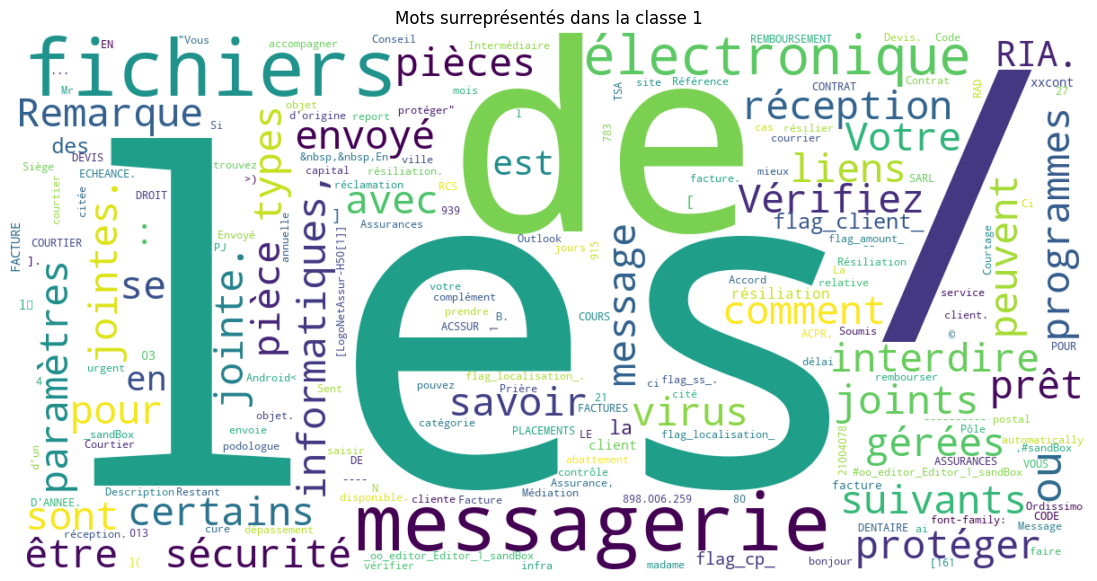

In [17]:
# Nuage de mots des churns qui ne sont pas dans les non churn
differential_wordcloud(central, positive_class=1, negative_class=0)

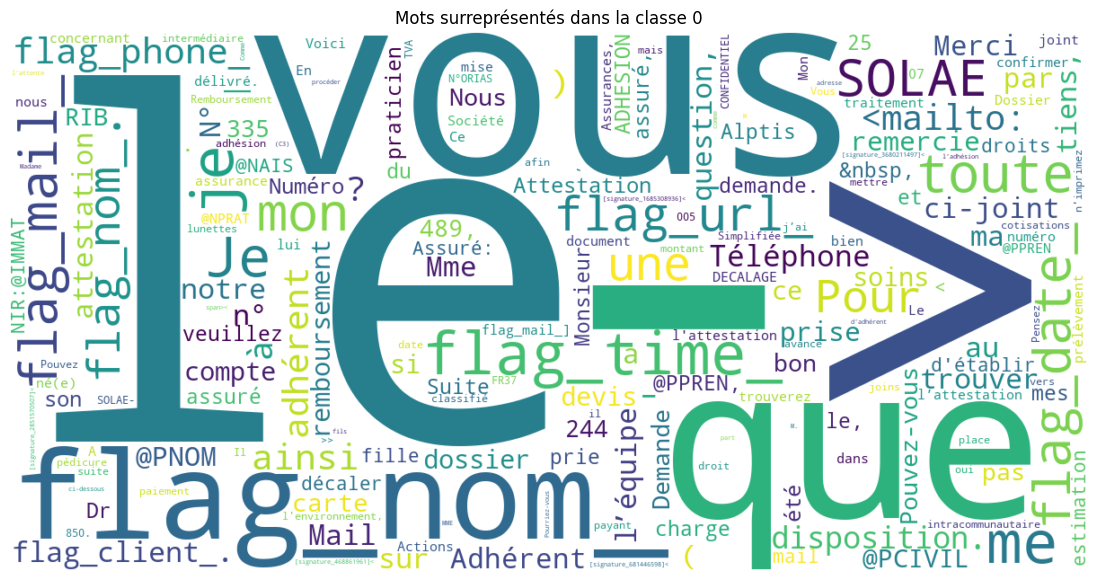

In [18]:
# Nuage de mot des churns
differential_wordcloud(central, positive_class=0, negative_class=1)

In [19]:
# Comparaison des topics par classe et affichage des mots des topics associés à la classe 1
def topic_class_summary(df, topic_col="topics", class_col="target_resiliation_6mois"):
    tab = pd.crosstab(df[topic_col], df[class_col])

    # sécuriser si colonnes absentes
    if 0 not in tab.columns:
        tab[0] = 0
    if 1 not in tab.columns:
        tab[1] = 0

    tab = tab[[0, 1]]
    tab.columns = ["class_0", "class_1"]

    tab["share_class_0"] = round(100 * tab["class_0"] / tab["class_0"].sum(), 3)
    tab["share_class_1"] = round(100 * tab["class_1"] / tab["class_1"].sum(), 3)
    tab["diff_1_minus_0"] = round( tab["share_class_1"] - tab["share_class_0"], 3)

    return tab.sort_values("diff_1_minus_0", ascending=False)

In [20]:
## Summary des topics
pd.set_option('display.max_rows', 20)
topic_summary = topic_class_summary(central)
topic_summary.head(20)

,class_0,class_1,share_class_0,share_class_1,diff_1_minus_0
topics,,,,,
41,28,209,0.035,1.240,1.205
56,21,163,0.026,0.967,0.941
90,12,117,0.015,0.694,0.679
98,32,92,0.040,0.546,0.506
12,523,191,0.657,1.133,0.476
25,259,132,0.325,0.783,0.458
72,78,76,0.098,0.451,0.353
121,46,58,0.058,0.344,0.286
74,88,63,0.111,0.374,0.263


In [21]:
## Top 10 des topics surreprésenté dans la classe des churn et les mots associés
top_topics_class1 = topic_summary.head(30).index.tolist()

for t in top_topics_class1:
    print(f"\nTopic {t}")
    print(topic_model.get_topic(t))


Topic 41
[('flag_nom_ ria', np.float64(0.029188613840246024)), ('messagerie électronique', np.float64(0.027813102036252643)), ('messagerie', np.float64(0.02721746774623735)), ('fichiers', np.float64(0.02683540210483548)), ('électronique', np.float64(0.025650893357622353)), ('ria votre', np.float64(0.02300586612606208)), ('jointes flag_client_', np.float64(0.019267048264813513)), ('gérées les', np.float64(0.019095766647928693)), ('gérées', np.float64(0.019095766647928693)), ('jointe vérifiez', np.float64(0.019095766647928693))]

Topic 56
[('messagerie électronique', np.float64(0.028301295500142442)), ('messagerie', np.float64(0.02769520625379487)), ('fichiers', np.float64(0.027306434350406614)), ('électronique', np.float64(0.026101134343464314)), ('ria votre', np.float64(0.02340967989193501)), ('jointes flag_client_', np.float64(0.019474305569305277)), ('gérées', np.float64(0.019430947831722303)), ('jointe vérifiez', np.float64(0.019430947831722303)), ('gérées les', np.float64(0.019430

In [22]:
## Word cloud des mots d'un topic donné
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_topic_wordcloud(topic_model, topic_id, title=None):
    topic_words = topic_model.get_topic(topic_id)

    if topic_words is None:
        print(f"Aucun mot trouvé pour le topic {topic_id}")
        return

    freqs = {word: weight for word, weight in topic_words}

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white"
    ).generate_from_frequencies(freqs)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title or f"Topic {topic_id}")
    plt.show()

In [23]:
# Visulaliser des exemple d'email pour la classe des churns en fonction du topic
def show_example_emails(df, topic_id, class_value=None, text_col="objet_contenu", n=8):
    sub = df[df["topics"] == topic_id].copy()
    if class_value is not None:
        sub = sub[sub["target_resiliation_6mois"] == class_value]

    examples = sub[text_col].dropna().sample(n).tolist()
    for i, txt in enumerate(examples, 1):
        print(f"\n--- Exemple {i} ---\n{txt[:1000]}")

#show_example_emails(df=central, topic_id=17, class_value=1)

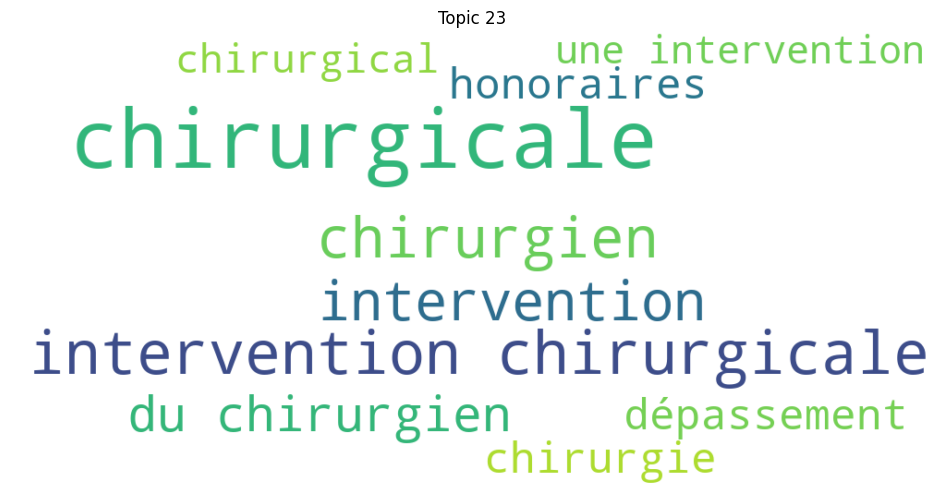

In [24]:
# Affichage des topics pertinents
plot_topic_wordcloud(topic_model, topic_id=23, title=f"Topic 23")

In [25]:
# Exemple de mails
show_example_emails(df=central, topic_id=23, class_value=1)


--- Exemple 1 ---
Demande de Devis pour lobectomie. Veuillez trouver en pièce jointe une demande de devis pour une lobectomie qui aura lieu le  flag_date_  Dans l'attente de ce devis, veuillez agréer, Madame, Monsieur, mes cordiales salutations    flag_nom_ 

--- Exemple 2 ---
Factures Opération Chirurgie Refractive Mars 2023. *N° Adhérent :  flag_client_ *    Veuillez trouver ci-joint les factures correspondant à mon intervention de chirurgie réfractive du  flag_date_ . S'il vous faut également les documents par courrier, merci de m'en faire part et je vous les enverrai. Je suis disponible pour toutes questions supplémentaires.

--- Exemple 3 ---
devis chirurgie cataracte  /  MR flag_nom_   /   flag_client_. Veuillez trouver ci-joint les factures pour traitement

--- Exemple 4 ---
rembourseemnt en attente. Ci joint voici 2 documents dont vous avez peut être besoin pour régler les remboursements me restant dû de cette intervention chirurgicale du  flag_date_    

--- Exemple 5 ---
Dev

## Modèle 1 : suppression des topics bruits en amont

In [26]:
# Fonction de nettoyage du texte en amont du BERTopic
!python -m spacy download fr_core_news_md

import re
import unicodedata
import spacy


nlp = spacy.load("fr_core_news_md")

EMAIL_NOISE_PATTERNS = [
    # placeholders / balises techniques
    r"\bflag_[a-zA-Z0-9_]+\b",
    r"\bxx(?:pj\d*|obj|cont)\b",
    
    # formules de politesse / ouverture / clôture
    r"\bbonjour\b",
    r"\bbonsoir\b",
    r"\bcordialement\b",
    r"\bbien cordialement\b",
    r"\bmerci d['’]avance\b",
    r"\bje vous remercie\b",
    r"\bà votre disposition\b",
    
    # mentions pièces jointes / messagerie
    r"\bpi[eè]ce(?:s)? jointe(?:s)?\b",
    r"\bvoir pi[eè]ce(?:s)? jointe(?:s)?\b",
    r"\bci[- ]jointe(?:s)?\b",
    r"\bmessagerie [ée]lectronique\b",
    
    # entêtes / transferts / réponses
    r"\bobjet\s*:",
    r"\bde\s*:",
    r"\benvoy[ée] le\s*:",
    r"\bdate\s*:",
    r"\bfrom\s*:",
    r"\bto\s*:",
    r"\bsubject\s*:",
    r"\bre\s*:",
    r"\btr\s*:",
    r"\bfwd\s*:",
    
    # urls / mails
    r"https?://\S+",
    r"\b\S+@\S+\.\S+\b",
    
    # références automatiques
    r"\bref\s*:\s*[_a-zA-Z0-9\.-]+\b",

    # Phrases automatiques
    r"\bRemarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.\b"
]

CUSTOM_STOPWORDS = {
    "bonjour", "bonsoir", "cordialement", "merci", "avance",
    "piece", "jointe", "pieces", "jointes",
    "messagerie", "electronique",
    "objet", "date", "envoyer", "envoyé", "envoyee",
    "re", "tr", "fwd", "message", "from", "android", "outlook"
}

def strip_accents(text: str) -> str:
    text = unicodedata.normalize("NFKD", text)
    return "".join(c for c in text if not unicodedata.combining(c))

def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.replace("\r", " ").replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def remove_noise_patterns(text: str) -> str:
    text = normalize_text(text)
    for pattern in EMAIL_NOISE_PATTERNS:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_french_email_tokens(
    text: str,
    keep_negation: bool = True,
    min_token_len: int = 2
) -> str:
    text = remove_noise_patterns(text)
    if not text:
        return ""
    
    doc = nlp(text)
    cleaned_tokens = []
    
    negation_words = {"ne", "pas", "plus", "jamais", "aucun", "rien"}
    
    for token in doc:
        if token.is_space or token.is_punct:
            continue
        
        lemma = token.lemma_.lower().strip()
        surface = token.text.lower().strip()
        
        # fallback si lemma absent ou bizarre
        if not lemma or lemma == "-pron-":
            lemma = surface
        
        lemma_no_acc = strip_accents(lemma)
        
        # garder la négation si souhaité
        if keep_negation and lemma_no_acc in negation_words:
            cleaned_tokens.append(lemma_no_acc)
            continue
        
        # stopwords généraux spaCy + stopwords métier/email
        if token.is_stop:
            continue
        if lemma_no_acc in CUSTOM_STOPWORDS:
            continue
        
        # filtrage tokens parasites
        if re.fullmatch(r"[_\W\d]+", lemma_no_acc):
            continue
        if len(lemma_no_acc) < min_token_len:
            continue
        
        cleaned_tokens.append(lemma_no_acc)
    
    return " ".join(cleaned_tokens)

     ---------------------------------------- 0.0/45.8 MB ? eta -:--:--
     --------------------------------------- 0.0/45.8 MB 320.0 kB/s eta 0:02:24
     --------------------------------------- 0.1/45.8 MB 656.4 kB/s eta 0:01:10
      --------------------------------------- 0.9/45.8 MB 7.2 MB/s eta 0:00:07
     --- ------------------------------------ 3.5/45.8 MB 20.2 MB/s eta 0:00:03
     ----- ---------------------------------- 5.7/45.8 MB 26.2 MB/s eta 0:00:02
     ------- -------------------------------- 8.2/45.8 MB 32.7 MB/s eta 0:00:02
     -------- ------------------------------- 9.3/45.8 MB 31.4 MB/s eta 0:00:02
     -------- ------------------------------ 10.5/45.8 MB 50.4 MB/s eta 0:00:01
     -------- ------------------------------ 10.5/45.8 MB 50.4 MB/s eta 0:00:01
     -------- ------------------------------ 10.5/45.8 MB 50.4 MB/s eta 0:00:01
     --------- ----------------------------- 11.5/45.8 MB 25.1 MB/s eta 0:00:02
     ----------- --------------------------- 13.5

In [27]:
# Nettoyage du contenu des emails et embeddings

## Nettoyage
df_email_level['objet_contenu_clean'] = [
    clean_french_email_tokens(t) if isinstance(t, str) else ""
    for t in df_email_level['objet_contenu']
]

In [28]:
df_email_level['objet_contenu_clean']

1                                                                                                         alptis augmentation prime accord mois offrir adhesion
3                                                                                                                             salir joint demande remboursement
9                                                                                                                           accord mois offrir abattement fidel
12        adherent noter mere monsieur numero adherent alptis etre hospitaliser urgence l suite dun leger avc etat samelior devoir diriger jour etablisse...
13        resiliation contrat suite deces convenir trouver acte deces mr degre adherent resilier compte conserver mere rib prelevement remboursement prestat...
                                                                                  ...                                                                          
251783                                  

In [ ]:
## Embeddings

embeddings_model_name = "paraphrase-multilingual-MiniLM-L12-v2"
embeddings_model = SentenceTransformer(embeddings_model_name)

docs = df_email_level['objet_contenu_clean'].tolist()
embeddings = embeddings_model.encode(
    docs,
    show_progress_bar=True,
    batch_size=256
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12738.72it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 1508/1508 [09:01<00:00,  2.79it/s]


In [30]:
# Etape 2 : Ajustement
## Définition des topics
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

## Initialisation 
umap_model = UMAP(
    n_neighbors=20,
    n_components=8,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    ngram_range=(1,2),
    min_df=5
)

topic_model = BERTopic(
    embedding_model=embeddings_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

## Entrainer le modèle
topics, probs = topic_model.fit_transform(docs, embeddings)

2026-04-22 02:56:23,293 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-22 02:58:40,987 - BERTopic - Dimensionality - Completed ✓
2026-04-22 02:58:40,987 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-22 03:33:48,569 - BERTopic - Cluster - Completed ✓
2026-04-22 03:33:48,610 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-22 03:33:50,857 - BERTopic - Representation - Completed ✓


In [31]:
# Fusionner les topics obtenus avec la base des cliens

df_email_level["topics"] = topics
if probs is not None:
    df_email_level['topic_confidence'] = probs.max(axis=1)
else:
    df_email_level['topic_confidence'] = None
df_email_level[["client_code", "interaction_date", "topics"]].shape

# Feature de comptage des topics par client
topic_counts = (
    df_email_level
    .groupby(["client_code", "topics"])
    .size()
    .unstack(fill_value=0)
    .add_prefix("topic_count_")
)
print(f"Taille du dataset : {topic_counts.shape}")
topic_counts.head(5)

# Nombre d'email par client et topic dominant
client_stats = (
    df_email_level.groupby("client_code")
    .agg(
        n_emails=("objet_contenu_clean", "count"),
        n_topics_distinct=("topics", "nunique"),
        mean_topic_confidence=("topic_confidence", "mean")
    )
)
print(f"Taille du dataset : {client_stats.shape}")
client_stats.head(5)

# Aggrégation avec data Portefeuille

## Accès à la donnée source
df_portefeuille = pd.read_csv("data/apprentissage_portefeuille_2023_11.csv", sep=";")
df_portefeuille = df_portefeuille[["client_code", "target_resiliation_6mois"]]

## Function : Merging DataFrame
def dataframe_merge(input_df1: pd.DataFrame, input_df2: pd.DataFrame, id_1: 'str', id_2: 'str'):
    df_merged = pd.merge(left=input_df1, right=input_df2, how="inner", left_on=id_1, right_on=id_2)
    df_outter = pd.merge(left=input_df1, right=input_df2, how="outer", left_on=id_1, right_on=id_2, indicator=True)
    df_left = df_outter[df_outter["_merge"]=="left_only"]
    df_right = df_outter[df_outter["_merge"]=="right_only"]
    return df_merged, df_left, df_right

## Fusion des datasets
central, left, right = dataframe_merge(df_portefeuille, df_email_level, id_1="client_code", id_2="client_code")

Taille du dataset : (36280, 549)
Taille du dataset : (36280, 3)


C:\Users\h-daniel.karamoko\AppData\Local\Temp\ipykernel_220328\2724809133.py:36: DtypeWarning: Columns (0: client_nps_date_reponse_n_moins1, 1: client_nps_verbatim_n_moins1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_portefeuille = pd.read_csv("data/apprentissage_portefeuille_2023_11.csv", sep=";")


In [32]:
## Summary des topics
pd.set_option('display.max_rows', 20)
topic_summary = topic_class_summary(central)
topic_summary.head(20)

## Top 10 des topics surreprésenté dans la classe des churn et les mots associés
top_topics_class1 = topic_summary.head(30).index.tolist()

for t in top_topics_class1:
    print(f"\nTopic {t}")
    print(topic_model.get_topic(t))


Topic 3
[('resiliation', np.float64(0.032204130835268734)), ('demande resiliation', np.float64(0.01751166160022647)), ('resiliation contrat', np.float64(0.015255412817870052)), ('resilier', np.float64(0.011939346631699939)), ('report', np.float64(0.01045901750421577)), ('reporter', np.float64(0.009702053572136382)), ('infra', np.float64(0.009009856552433223)), ('refus', np.float64(0.008896573146277271)), ('resiliation infra', np.float64(0.008823806454154195)), ('refus resiliation', np.float64(0.0087635908116754))]

Topic 103
[('ria pret', np.float64(0.043033737732955296)), ('fichier', np.float64(0.042749359911949655)), ('savoir gerer', np.float64(0.03656419999370387)), ('fichier verifier', np.float64(0.03656419999370387)), ('virus informatique', np.float64(0.03653637510116104)), ('parametre securite', np.float64(0.03653637510116104)), ('reception type', np.float64(0.03653637510116104)), ('securite savoir', np.float64(0.03653637510116104)), ('proteger virus', np.float64(0.0365363751011

------------------------------------------------------
        Topic identifié 3
------------------------------------------------------


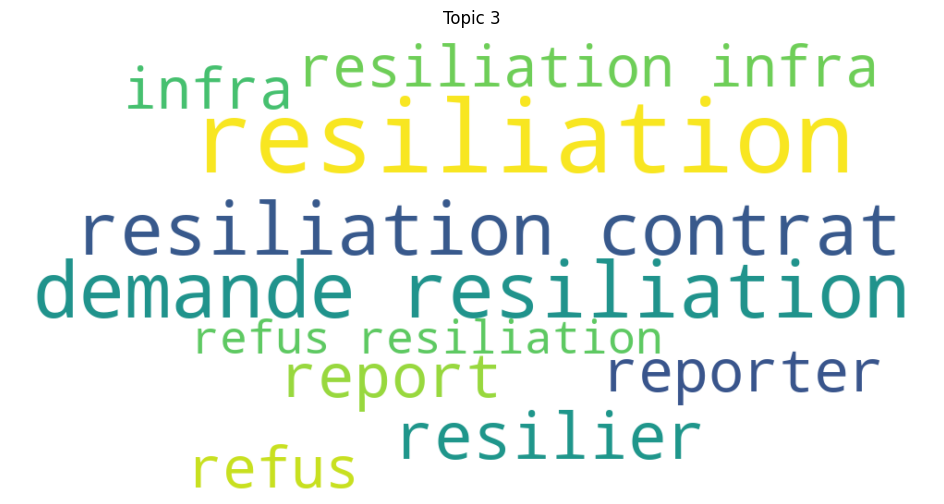

Quelques exemples de mails du topic 3

--- Exemple 1 ---
Courtier  flag_client_  - M. flag_nom_  - N°  flag_client_  - Report. Lancienne mutuelle ayant refusé la résiliation, veuillez reporter la date deffet du contrat au  flag_date_  svp. Vous trouverez ci-joint le justificatif

--- Exemple 2 ---
Contrat. Je vous est envoyé un mail de MELEINE par lequel je voulais résilier avec vous  mais j'ai fait une rétractation  et je vous demande  de refuser leur avis

--- Exemple 3 ---
Demande de résiliation n° flag_client_. Suite à notre échange téléphonique, je souhaite vous transmettre le document nécessaire pour ma résiliation de contrat. Veuillez trouver ci-joint mon attestation de billet d'avion qui prouve que je pars à l'étranger. Merci de résilier le contrat au  flag_date_  et d'envoyer l'attestation de résiliation. N'hésitez pas à me contacter si besoin.

--- Exemple 4 ---
flag_client_  - Madame flag_nom_. Ce mail concerne la Résiliation du contrat d’assurance pour flag_nom_ . L’affil

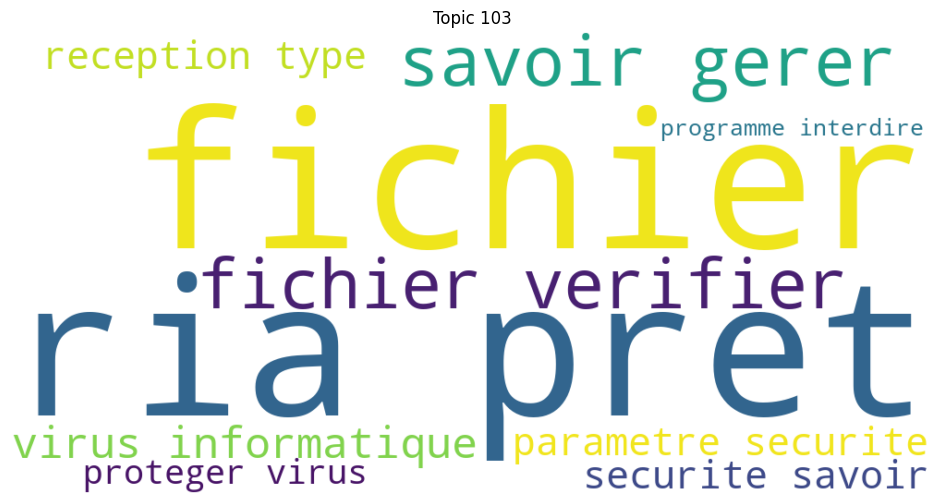

Quelques exemples de mails du topic 103

--- Exemple 1 ---
flag_client_  GENET ANDRE  /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  2445798224   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
flag_client_  BOYER BESSON MARIE  /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  9923305389   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
flag_client_  MENOCHET THERESE  /  RIA. Votre 

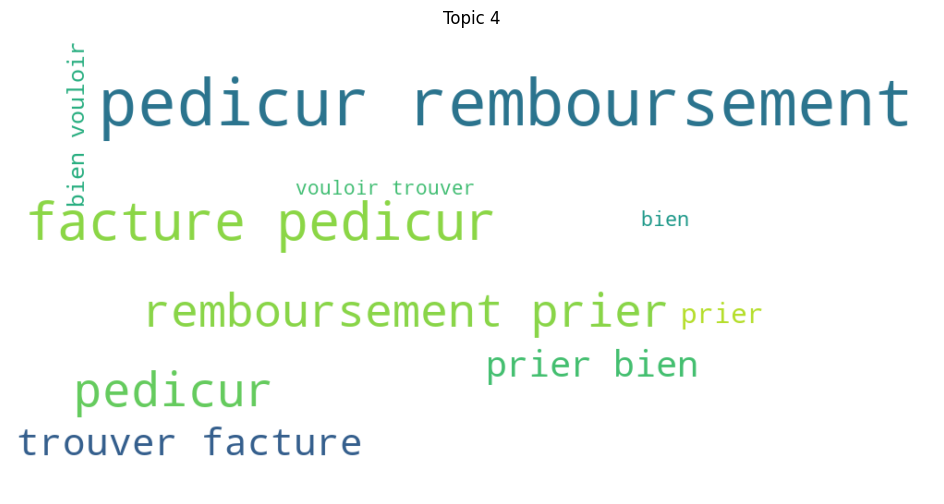

Quelques exemples de mails du topic 4

--- Exemple 1 ---
. 

--- Exemple 2 ---
flag_client_  flag_nom_. * flag_client_  flag_nom_ *  ----------  

--- Exemple 3 ---
xxcont   . 

--- Exemple 4 ---
. 

--- Exemple 5 ---
xxcont   . 

--- Exemple 6 ---
xxcont   . 

--- Exemple 7 ---
xxcont   . 

--- Exemple 8 ---
xxcont   . 
------------------------------------------------------

------------------------------------------------------
        Topic identifié 124
------------------------------------------------------


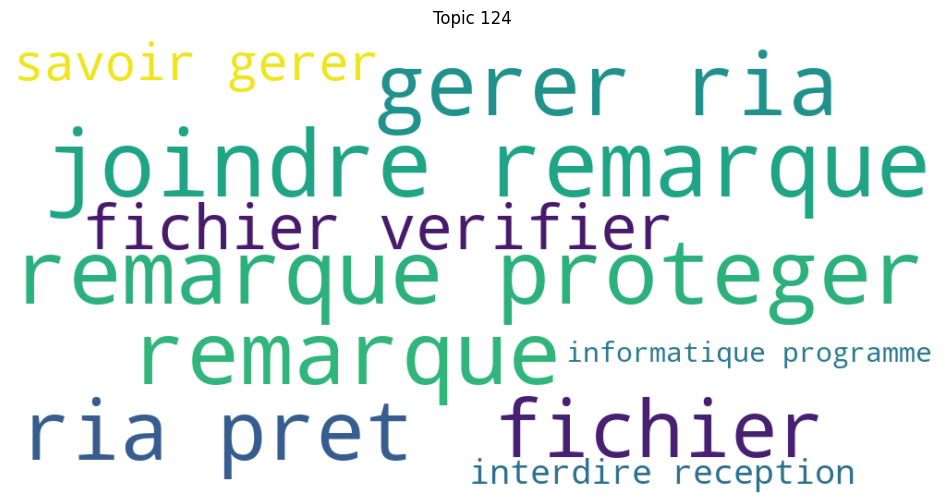

Quelques exemples de mails du topic 124

--- Exemple 1 ---
flag_client_  / RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  3639197483   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
flag_client_  flag_nom_   /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  7230809605   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
flag_client_  flag_nom_   /  RIA. Votre message est prêt à être envo

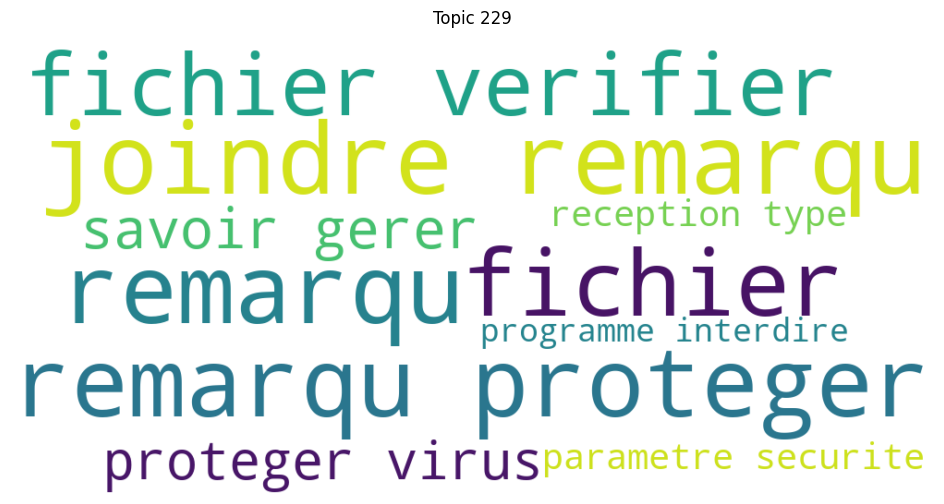

Quelques exemples de mails du topic 229

--- Exemple 1 ---
flag_client_  flag_localisation_   /  flag_localisation_. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  7196276835   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
flag_client_  flag_nom_   /  flag_nom_. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  7484002007   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
flag_client_  flag_locali

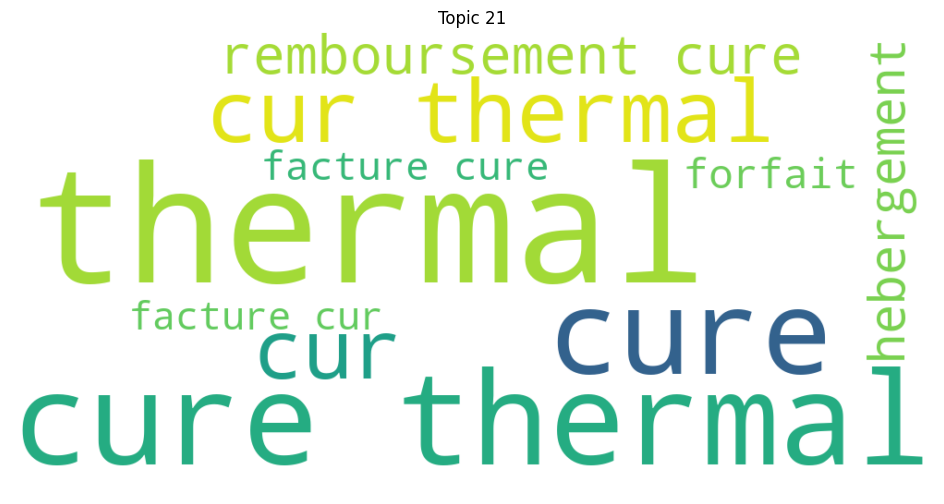

Quelques exemples de mails du topic 21

--- Exemple 1 ---
Relevé sécu client   flag_client_  flag_nom_. Bonjour, suite à sa cure thermale vous avez demandé au client son relevé sécurité sociale pour remboursement des soins du  flag_date_   flag_nom_   Conseiller en assurances   flag_phone_   11 rue flag_nom_  -  flag_cp_  flag_localisation_    [cid: flag_mail_ ]

--- Exemple 2 ---
cure thermale. ci joint 2 factures des thermes et la facture logement.

--- Exemple 3 ---
flag_nom_   flag_client_. Bonjour, ci joint facture de cure thermal de Mr et mme flag_nom_   flag_client_ . Ainsi que le décompte de sécu. Merci de traiter rapidement la demande svp car la cure date dejà du  flag_date_ et le client n'est tjrs pas remboursé  Sans <#DAB4FAD8-2DD flag_date_ BB-A1B8-4E2AA1F9FDF2>

--- Exemple 4 ---
frais cure thermale. Veuillez trouver en pièces jointes les 2 factures afin que je puisse obtenir mes remboursements le plus rapidement possible. Je voulais préciser par ailleurs que le décompte s

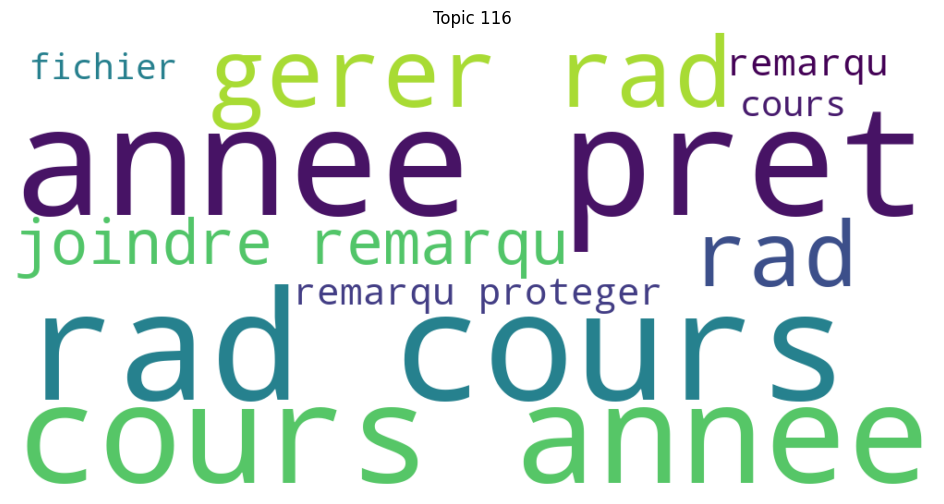

Quelques exemples de mails du topic 116

--- Exemple 1 ---
flag_client_  / RAD EN COURS D'ANNEE. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  8483801656   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
flag_client_  / RAD EN COURS D'ANNEE. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  6497732871   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
flag_client_  / RAD EN COURS D'ANNEE. Votre mes

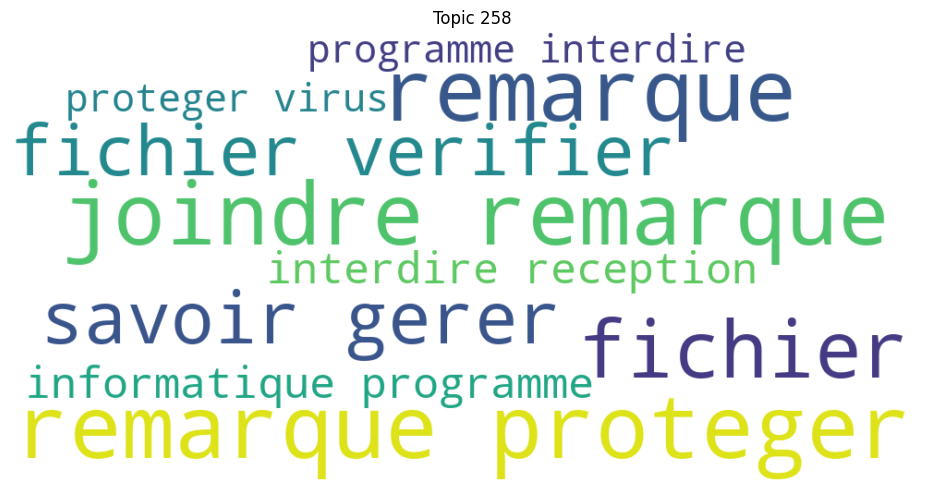

Quelques exemples de mails du topic 258

--- Exemple 1 ---
flag_client_  flag_nom_   /  flag_localisation_. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  7849267856   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
flag_client_  flag_nom_  / flag_nom_. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  4562554127   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
flag_client_  flag_nom_   /  flag_no

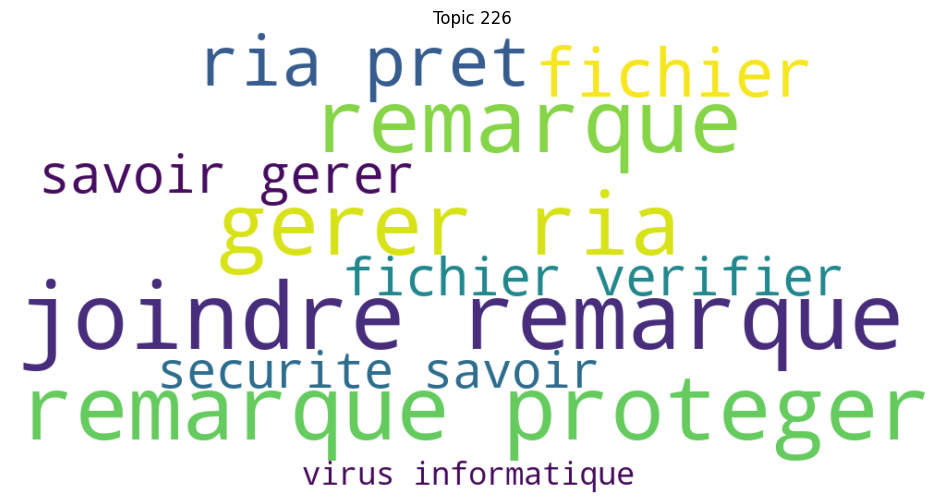

Quelques exemples de mails du topic 226

--- Exemple 1 ---
flag_client_   flag_nom_   /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  3636690557   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
flag_client_  / RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  9379463692   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
flag_client_  flag_nom_   /  RIA. Votre message est prêt à être env

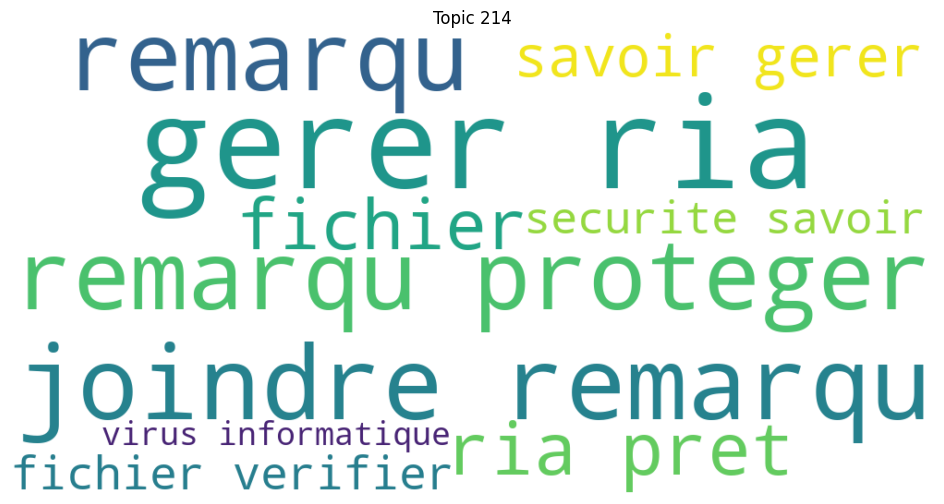

Quelques exemples de mails du topic 214

--- Exemple 1 ---
flag_client_  flag_nom_   /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  6390105341   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
flag_client_  flag_nom_   /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  1472100038   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
flag_client_  flag_nom_   /  RIA. Votre message est prê

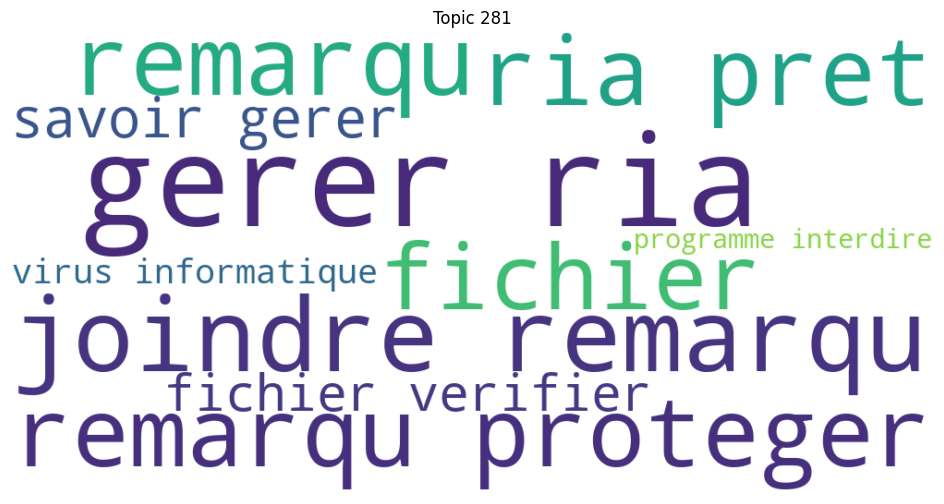

Quelques exemples de mails du topic 281

--- Exemple 1 ---
flag_client_  flag_nom_   /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  2877698237   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
flag_client_  flag_nom_   /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  4090563663   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
flag_client_  flag_nom_   /  RIA. Votre message est prê

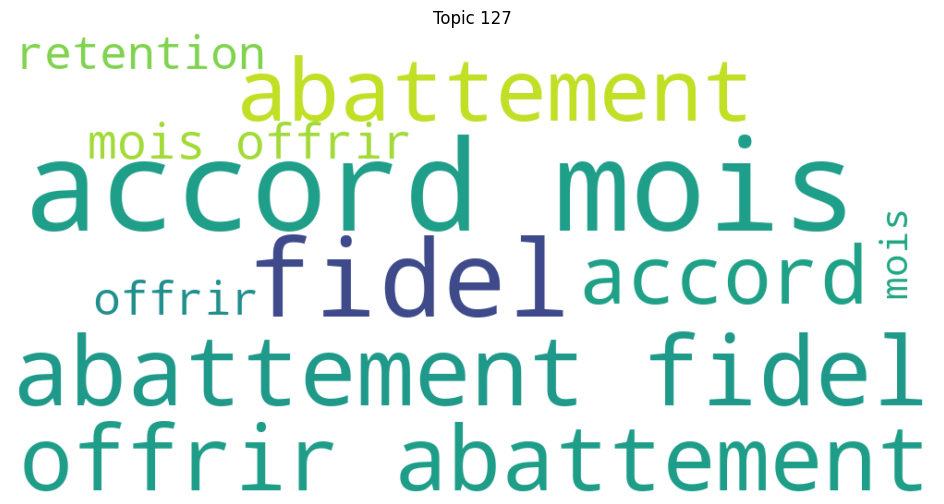

Quelques exemples de mails du topic 127

--- Exemple 1 ---
DEMANDE GESTE COMMERCIAL  /  DÉFENSE PORTEFEUILLE 01.01.2023. Accord pour ces 3 demandes 1 mois retention santé   

--- Exemple 2 ---
Demande de mois offert -  flag_client_. Merci d'appliquer un mois offert pour notre adhérent avec le code FIDLCOURT, l'accord de mon responsable régional est joint ci-dessous.  

--- Exemple 3 ---
Erreur échéancier 2023 flag_nom_   flag_client_. Accord 1 mois retention santé   

--- Exemple 4 ---
réclamation contrat flag_nom_  N° flag_client_. Accord pour 1 mois offert   

--- Exemple 5 ---
suivi Désaccord échéancier 2023 Alptis  flag_client_  flag_nom_ PTIS ASSURANCES flag_nom_  et flag_nom_. Accord pour 1 mois offert   

--- Exemple 6 ---
Santé select. Accord 1 mois offert : abattement fidel   *    flag_client_  *    flag_client_ 

--- Exemple 7 ---
Site PRXD Contact Santé  /  Prévoyance flag_nom_. Accord 1 mois rétention santé Adhérent N°  flag_client_ .  

--- Exemple 8 ---
DOSSIER MADAME fla

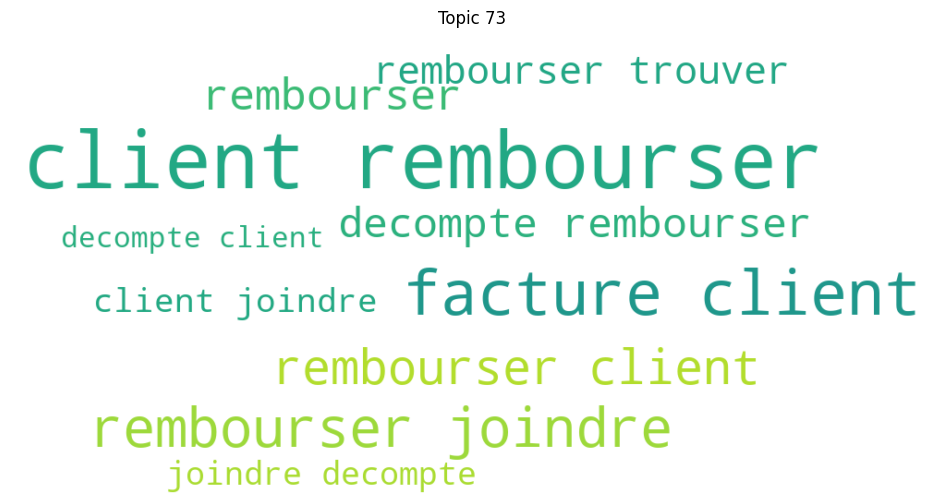

Quelques exemples de mails du topic 73

--- Exemple 1 ---
flag_client_  flag_nom_. Je vous envoie ci joint les factures de la cliente à rembourser

--- Exemple 2 ---
flag_client_  flag_localisation_. Je vous envoie ci joint les factures de la cliente à rembourser

--- Exemple 3 ---
flag_client_  flag_nom_    je vous envoie ci joint une facture de la cliente à rembourser. 

--- Exemple 4 ---
flag_client_  Assouline. je vous envoie ci joint les factures du client à rembourser

--- Exemple 5 ---
flag_client_  DE flag_nom_. je vous envoie ci joint les factures et les ordonnance du client à rembourser

--- Exemple 6 ---
flag_client_  flag_nom_. je vous envoie ci joint la facture de la cliente à rembourser

--- Exemple 7 ---
flag_client_  flag_nom_   flag_nom_. Je vous envoie ci joint une facture de la cliente à rembourser

--- Exemple 8 ---
Dossier  flag_client_. Merci de rembourser la facture du client Mme flag_nom_ .
------------------------------------------------------

----------------

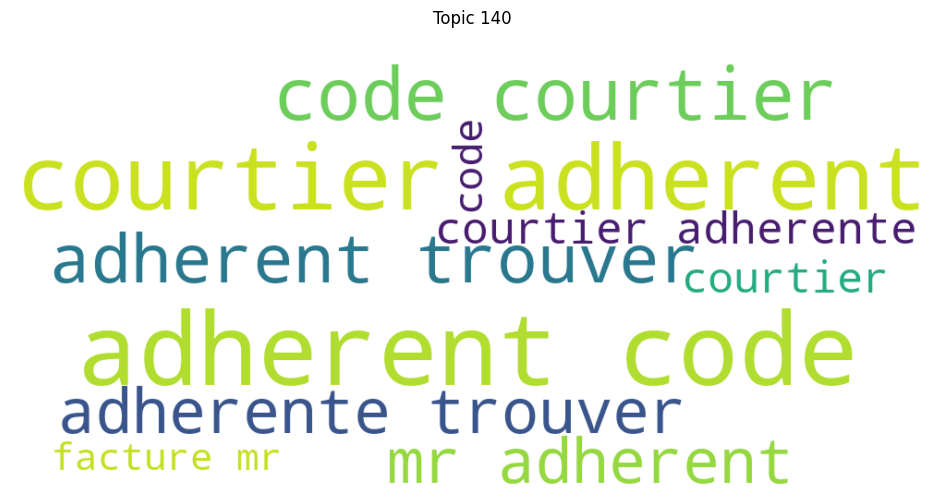

Quelques exemples de mails du topic 140

--- Exemple 1 ---
CODE COURTIER  flag_client_  ADHERENTE  flag_client_. Vous trouverez ci-joint une facture pour Mr flag_nom_  adhérent :  flag_client_ 

--- Exemple 2 ---
devis dentaire_ flag_nom_ _2228544. Code courtier :  flag_cp_

--- Exemple 3 ---
CODE COURTIER  flag_client_  ADHERENT  flag_client_. Vous trouverez ci-joint une facture pour Mme flag_nom_  adhérente :  flag_client_ 

--- Exemple 4 ---
CODE COURTIER  flag_client_  ADHERENT :  flag_client_. Vous trouverez ci-joint des factures et des devis pour Mr flag_nom_  adhérent :  flag_client_  Merci de traiter tous les documents.

--- Exemple 5 ---
CODE COURTIER  flag_client_  adhérente  flag_client_. Vous trouverez ci-joint deux factures pour flag_nom_  adhérente :  flag_client_ .

--- Exemple 6 ---
CODE COURTIER  flag_client_  ADHERENT  flag_client_. Vous trouverez ci-joint un relevé pour Mme flag_nom_  ADHÉRENTE  flag_client_  flag_nom_  veut être remboursée des  flag_amount_ .

--- E

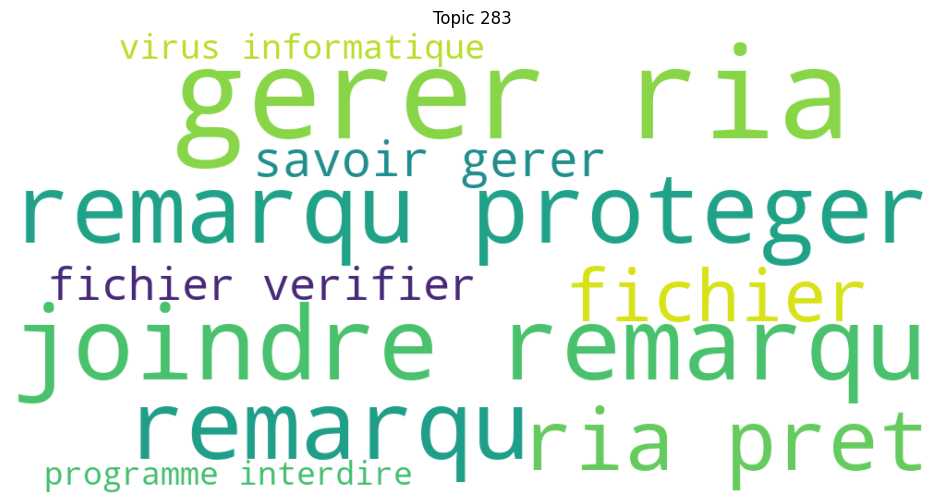

Quelques exemples de mails du topic 283

--- Exemple 1 ---
flag_client_  flag_nom_   /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  7755853818   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
flag_client_  flag_nom_   /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  7547448394   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
flag_client_  flag_nom_   /  RIA. Votre message est prê

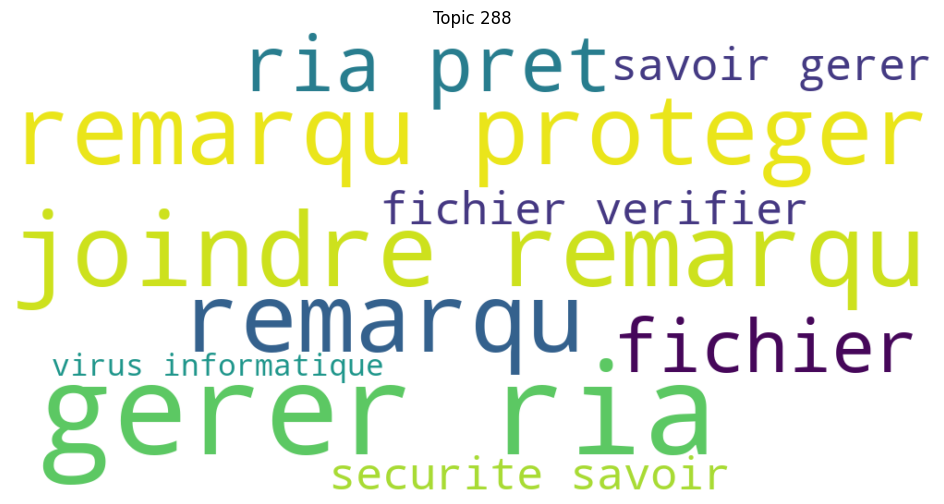

Quelques exemples de mails du topic 288

--- Exemple 1 ---
flag_client_  flag_localisation_   /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  8275441070   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
flag_client_  flag_nom_   /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  6164880409   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
flag_client_  flag_nom_   /  RIA. Votre messag

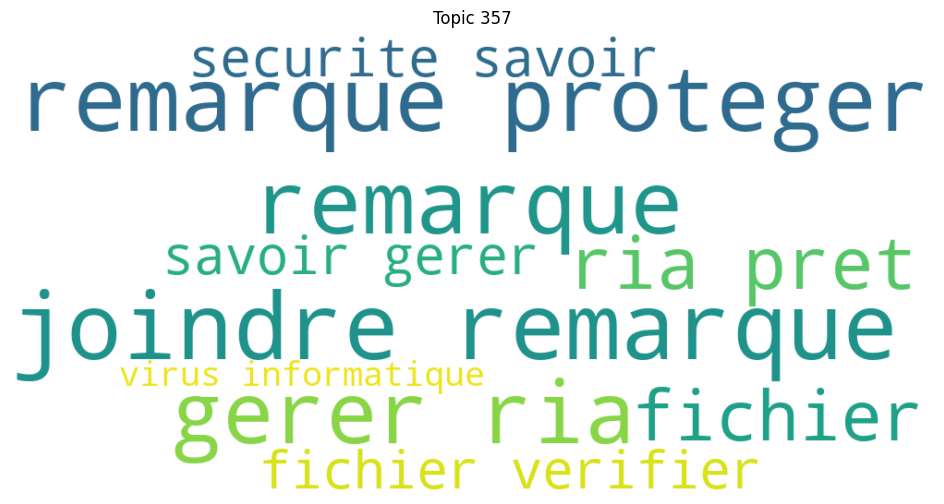

Quelques exemples de mails du topic 357

--- Exemple 1 ---
flag_client_  flag_nom_   /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  3364246385   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
flag_client_  flag_nom_  / RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  5857559017   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
flag_client_  flag_nom_   /  RIA. Votre message est prêt 

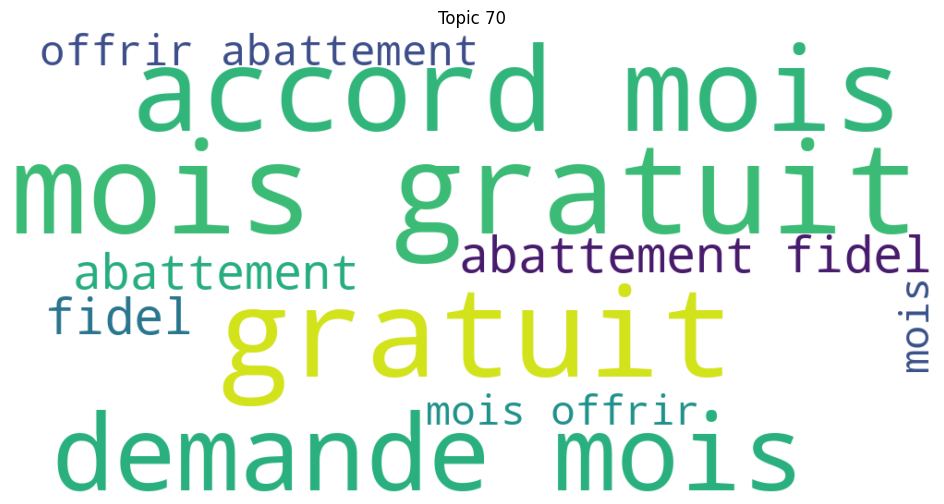

Quelques exemples de mails du topic 70

--- Exemple 1 ---
Demande de mois gratuit -  DE flag_localisation_   flag_client_. Accord pour 1 mois offert, abattement fidel. [cid: flag_mail_]

--- Exemple 2 ---
Opération Mois Gratuit - Merci d'avance.... flag_nom_ ont    Accord pour 1 mois offert pour ces 6 adhésions : programme FID 23. 1. M / Mme flag_nom_  N° CONTRAT :  flag_client_   2. Adhérent individuel  flag_client_  flag_nom_   1. Adhérent individuel  flag_client_  flag_nom_  2. flag_nom_  Adhérent individuel  flag_client_  3. flag_nom_  contrat N° flag_client_ . 4. flag_nom_  contrat N° flag_client_ . 

--- Exemple 3 ---
retention Augmentation mutuelle MOIS GRATUIT :. Accord 1 mois sur ces 3 demandes   

--- Exemple 4 ---
Demande de mois gratuit -  flag_client_  - flag_nom_. Accord pour 1 mois offert, abattement fidel.  

--- Exemple 5 ---
flag_nom_   flag_client_    /  /  1 MOIS GRATUIT. Accord pour 1 mois offert, abattement fidel.  

--- Exemple 6 ---
Demande mois gratuit augmenta

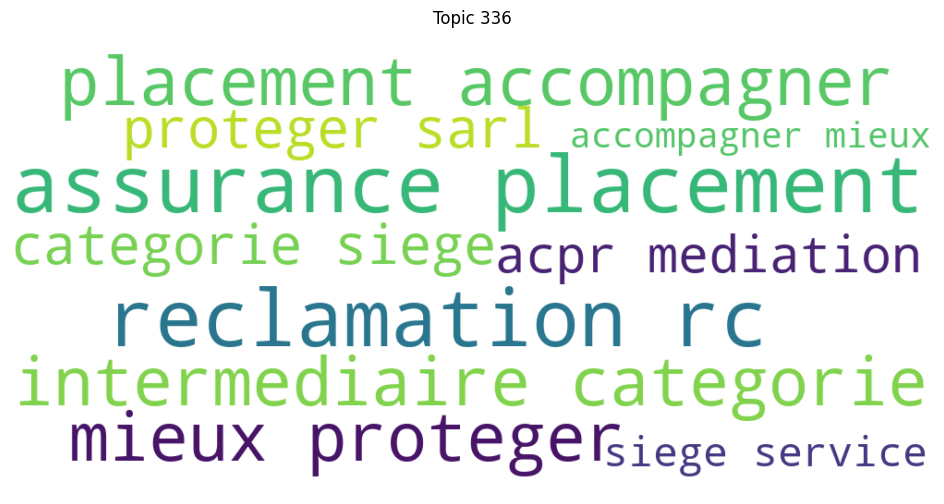

Quelques exemples de mails du topic 336

--- Exemple 1 ---
BORDEREAU flag_nom_ 	 flag_client_. [161 flag_phone_ ]       ASSURANCES - PLACEMENTS "Vous accompagner pour mieux vous protéger" 03 21 013 783       /      03 27 915 939   SARL de Courtage en Assurances au capital de  flag_amount_  - Intermédiaire de catégorie B.  Siège et service réclamation : 80 flag_localisation_  flag_nom_   flag_cp_  flag_nom_  RCS - flag_localisation_  898.006.259 - Orias 21004078 ( flag_url_ < flag_url_ >)  Soumis au contrôle de l ACPR, 4 flag_localisation_   flag_cp_   flag_cp_  flag_localisation_ . La Médiation de l Assurance, Pôle flag_localisation_ , TSA  flag_cp_   flag_cp_  flag_localisation_  ou  flag_mail_

--- Exemple 2 ---
FACTURE QUERSIN EDDY	 flag_client_. [161 flag_phone_ ]       ASSURANCES - PLACEMENTS "Vous accompagner pour mieux vous protéger" 03 21 013 783       /      03 27 915 939   SARL de Courtage en Assurances au capital de  flag_amount_  - Intermédiaire de catégorie B.  Siège et 

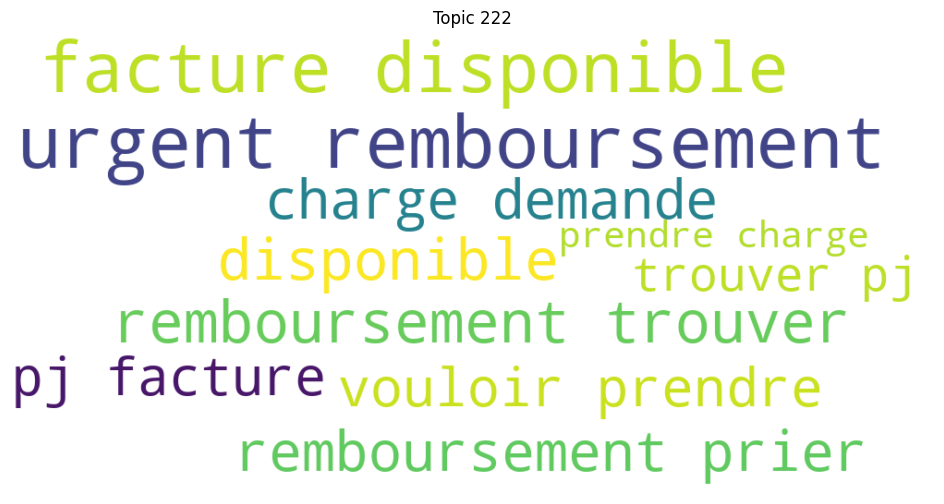

Quelques exemples de mails du topic 222

--- Exemple 1 ---
urgent remboursement  /  /  flag_nom_   /  /   flag_client_. Je vous prie de bien vouloir prendre en charge la demande de remboursement de M flag_nom_ , vous trouverez en PJ la facture. Restant disponible.

--- Exemple 2 ---
urgent remboursement  /  /  flag_nom_   /  /   flag_client_. Je vous prie de bien vouloir prendre en charge la demande de remboursement de M. flag_nom_    , vous trouverez en PJ la facture. Restant disponible.

--- Exemple 3 ---
urgent remboursement  /  /    flag_client_   /  /  flag_nom_. Je vous prie de bien vouloir prendre en charge la demande de remboursement de flag_nom_  , vous trouvez en PJ la facture. Restant disponible.

--- Exemple 4 ---
urgent remboursement  /  / °  flag_client_   /  / flag_nom_    Je vous en prie de trouver en pj un décompte pour remboursement   . 

--- Exemple 5 ---
Urgent remboursement  /  /   flag_client_   /  /  flag_nom_. Je vous prie de bien vouloir prendre en charge la de

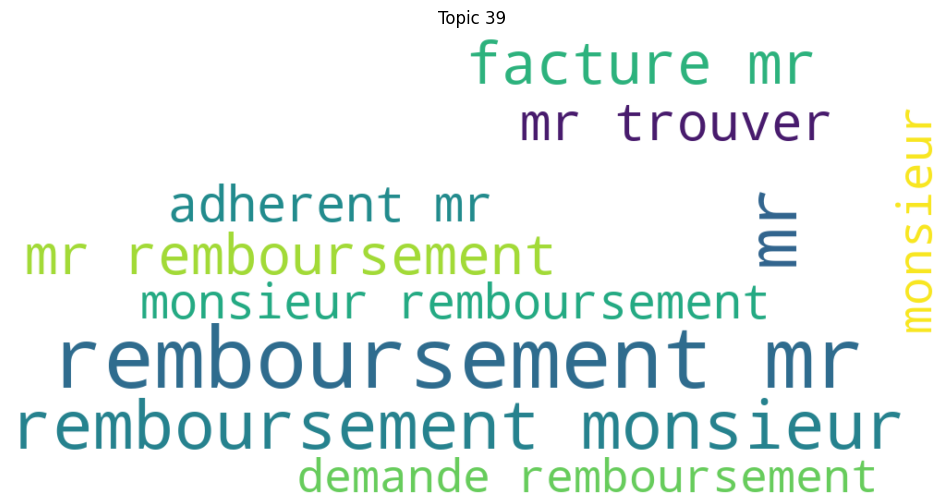

Quelques exemples de mails du topic 39

--- Exemple 1 ---
flag_client_  - Monsieur flag_nom_. Merci de procéder au remboursement de la facture ci-joint

--- Exemple 2 ---
Demande remboursement. Je vous prie de trouver ci-joint ma demande de remboursement Au nom de mr flag_nom_  mon conjoint Adhérent   flag_client_ 

--- Exemple 3 ---
flag_client_  - Madame flag_nom_. Je vous contacte pour obtenir le remboursement de l’avoir en cours.  

--- Exemple 4 ---
Facture  /  /   flag_client_    /  /  MR flag_nom_. Merci de trouver ci-joint des factures pour remboursement

--- Exemple 5 ---
flag_client_  - Monsieur flag_nom_. C est pour prolonger la remise de 20% sur mes cotisations .  

--- Exemple 6 ---
Facture examen à flag_localisation_  - adhérent  flag_client_. Vous trouverez ci-joint une facture d'examen concernant Mr flag_nom_  en vue du remboursement.

--- Exemple 7 ---
Remboursements factures. Voici les factures pour remboursements. Une concernant Mr flag_nom_    flag_client_  L'autre 

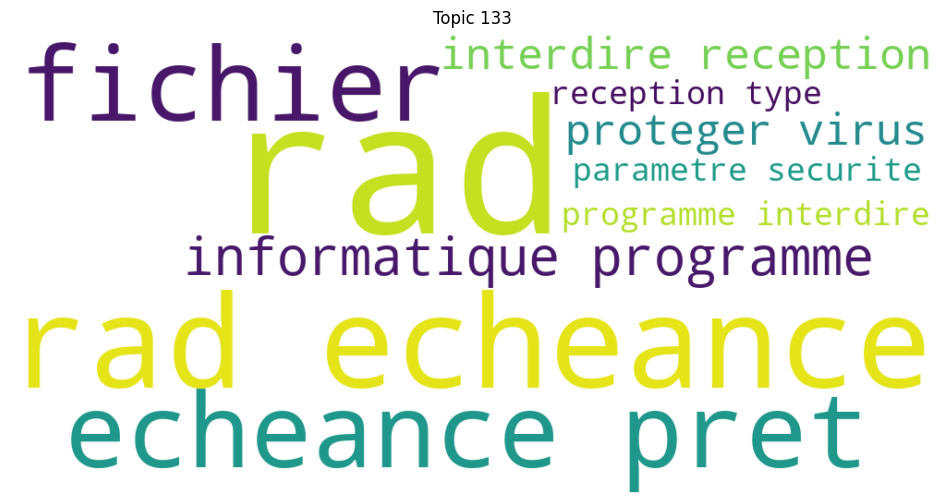

Quelques exemples de mails du topic 133

--- Exemple 1 ---
flag_client_  COUSIN MICHELINE  /  RAD POUR AUTRE RAISON. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  9526499782   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
flag_client_  ENGELVIN MAURICE / RAD ECHEANCE. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  6916688988   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
flag_client_  ROPA

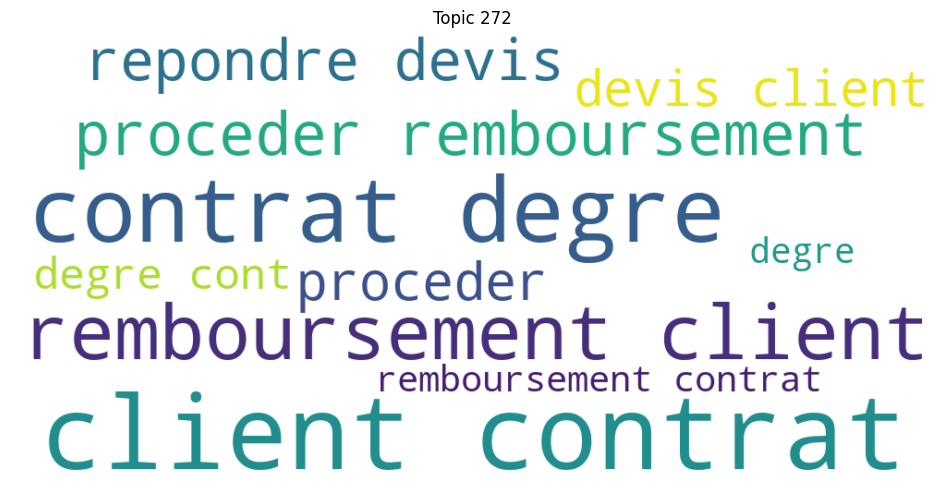

Quelques exemples de mails du topic 272

--- Exemple 1 ---
contrat N°  flag_client_  - flag_nom_      [LogoNetAssur-H50[1]]    Merci de procéder au remboursement pour ce client.. 

--- Exemple 2 ---
contrat N°  flag_client_  - flag_nom_. [LogoNetAssur-H50[1]]   Bonjour, Merci de procéder au remboursement pour ce client.

--- Exemple 3 ---
contrat N°  flag_client_  - Genin. [LogoNetAssur-H50[1]]   Merci de procéder au remboursement.

--- Exemple 4 ---
contrat N°  flag_client_  - flag_nom_. [LogoNetAssur-H50[1]]    Merci de répondre au devis du client.

--- Exemple 5 ---
contrat N°  flag_client_  - flag_nom_. [LogoNetAssur-H50[1]]    Merci de procéder au remboursement.

--- Exemple 6 ---
contrat N°  flag_client_  - flag_nom_      [LogoNetAssur-H50[1]]    Le client souhaite être prélevé le 10 de chaque mois. Merci de bien vouloir le modifier en conséquence.. 

--- Exemple 7 ---
contrat n°  flag_client_  - flag_nom_. [LogoNetAssur-H50[1]]    Merci de répondre au devis du client.

--- Exemp

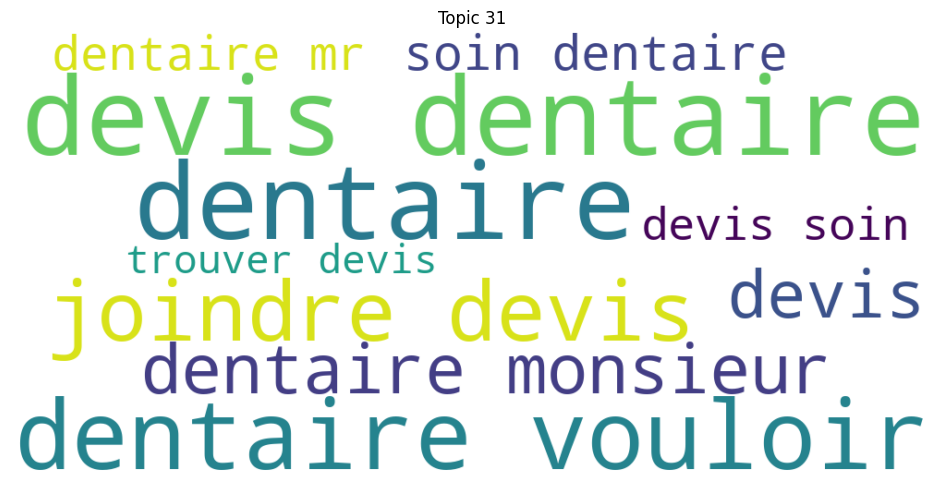

Quelques exemples de mails du topic 31

--- Exemple 1 ---
Demande pour remboursement facture dentiste. Veuillez trouver ci joint une facture d'honoraires d'un montant de  flag_amount_  concernant mon chirurgien dentiste  Docteur flag_nom_   Voici les renseignements me concernant :  Madame flag_nom_   N° adhérent ALPTIS:  flag_client_   Date de naissance:  flag_date_   N° Sécurité sociale :  flag_ss_   Adresse flag_localisation_  : flag_localisation_  n°  flag_date_  avenue flag_localisation_   flag_cp_  flag_localisation_  Portable :  flag_phone_   Adresse mail:  flag_mail_

--- Exemple 2 ---
Demande de prise en charge dentaire. Veuillez trouver ci-joint une demande de prise en charge  Vous en souhaitant bonne réception.

--- Exemple 3 ---
Devis dentaire flag_nom_   flag_client_. Veuillez trouver ci-joint un devis concernant le client cité en objet. Vous en souhaitant bonne réception.

--- Exemple 4 ---
Devis dentaire feuille no 3.. Veuillez noter 3 feuilles pour mon devis dentaire. fl

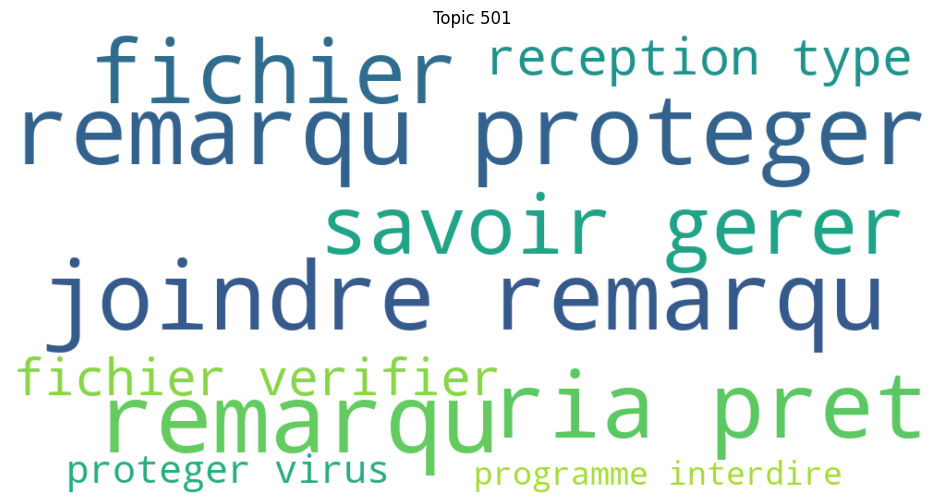

Quelques exemples de mails du topic 501

--- Exemple 1 ---
flag_client_  OSCHE GILLES  /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  2330716188   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
flag_client_  GIMIE MARIE CELINE  /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  3719931375   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
flag_client_  BRUN LAURA  /  RIA. Votre messa

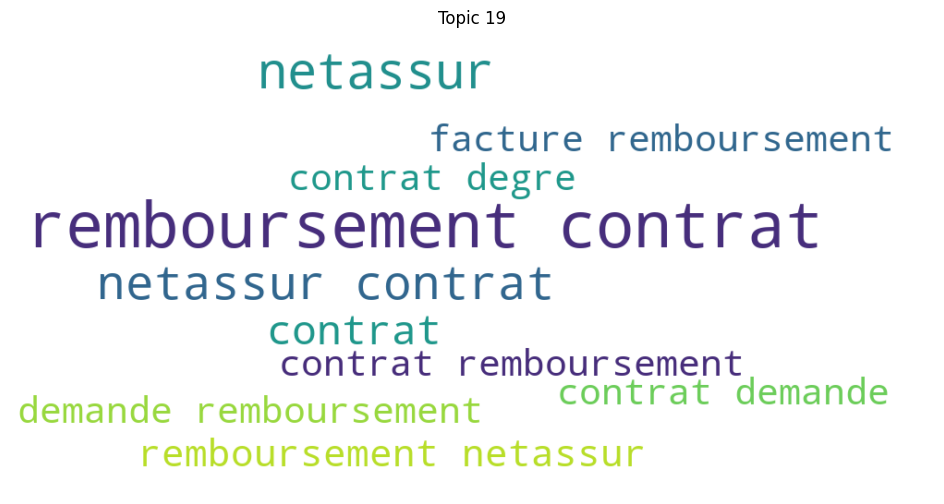

Quelques exemples de mails du topic 19

--- Exemple 1 ---
TR : TR : TR : contrat  flag_client_  flag_nom_. onjour Ci-jointe facture  pour remboursement

--- Exemple 2 ---
Remboursement.. Dans le cadre de ma garantie renfort bien être. Veuillez trouver ci-joint, original de ma facture de pédicure. Merci de m'adresser la partie contractuelle sur ses frais.

--- Exemple 3 ---
facture flag_nom_  - contrat  flag_client_. Ci-joint la facture acquittée de flag_nom_ . Merci de bien vouloir la traiter.

--- Exemple 4 ---
CONTRAT N°  flag_client_  - flag_nom_. Vous trouverez, ci-joint, un devis. Je vous remercie de bien vouloir nous indiquer le montant de votre remboursement. Dans l'attente de votre retour, et, avec mes remerciements,

--- Exemple 5 ---
Netassur: Contrat :  flag_client_  flag_localisation_. Veuillez trouver ci-joint les factures pour remboursement.

--- Exemple 6 ---
Votre demande de duplicata. bonsoir c est le contrat et les taux de remboursement cordialement  Le mar.  flag_dat

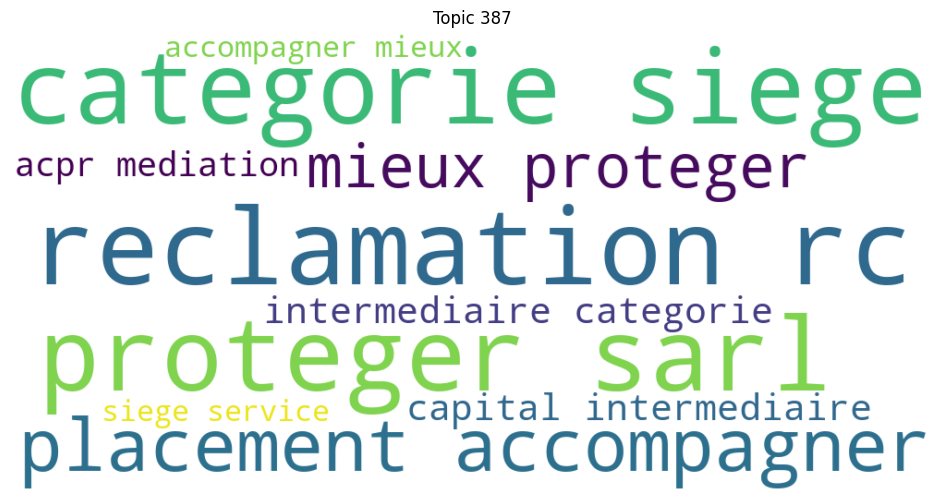

Quelques exemples de mails du topic 387

--- Exemple 1 ---
AFN  flag_client_  flag_nom_. [161 flag_phone_ ]   ASSURANCES - CRÉDITS - PLACEMENTS "Vous accompagner pour mieux vous protéger" 03 21 013 783       /      03 27 915 939   SARL de Courtage en Assurances au capital de  flag_amount_  - Intermédiaire de catégorie B.  Siège et service réclamation : 80 flag_localisation_   flag_cp_  flag_localisation_  RCS - flag_localisation_  898.006.259 - flag_nom_  21004078 ( flag_url_ < flag_url_ >)  Soumis au contrôle de l ACPR, 4 flag_localisation_   flag_cp_   flag_cp_  flag_localisation_ . La Médiation de l Assurance, Pôle flag_localisation_ , TSA  flag_cp_   flag_cp_  flag_localisation_  ou  flag_mail_

--- Exemple 2 ---
FACTURE  flag_client_  flag_nom_        [161 flag_phone_ ]   ASSURANCES - CRÉDITS - PLACEMENTS "Vous accompagner pour mieux vous protéger" 03 21 013 783       /      03 27 915 939   SARL de Courtage en Assurances au capital de  flag_amount_  - Intermédiaire de catégorie 

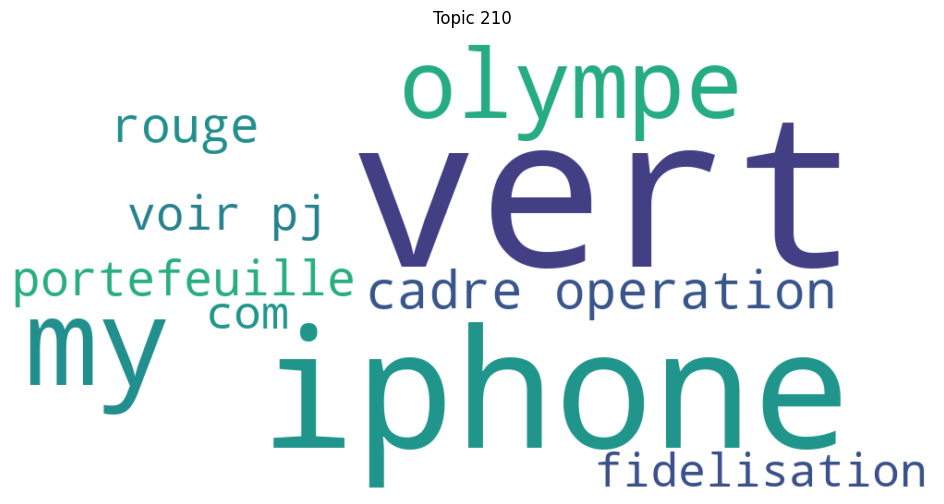

Quelques exemples de mails du topic 210

--- Exemple 1 ---
numéro d'adhérent :  flag_client_. Sent from my iPhone

--- Exemple 2 ---
numéro d'adhérent :  flag_client_. Sent from my iPhone

--- Exemple 3 ---
numéro d'adhérent :  flag_client_. Sent from my iPhone

--- Exemple 4 ---
numéro d'adhérent :  flag_client_. Sent from my iPhone

--- Exemple 5 ---
numéro adhérent :  flag_client_. Sent from my iPhone  Begin forwarded message:  

--- Exemple 6 ---
Adhérents  flag_client_. iPhone de Caty

--- Exemple 7 ---
N° adhérent :  flag_client_. Sent from my iPhone

--- Exemple 8 ---
numéro adhérent :  flag_client_. Sent from my iPhone
------------------------------------------------------

------------------------------------------------------
        Topic identifié 32
------------------------------------------------------


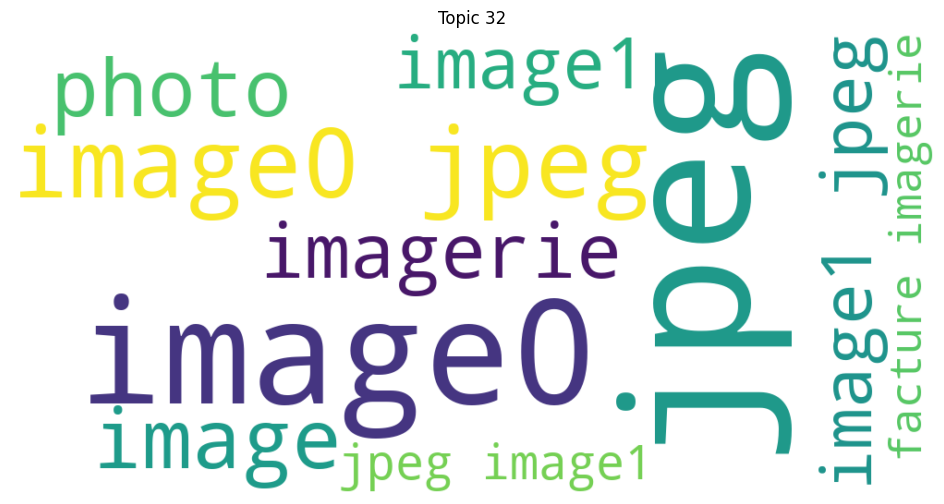

Quelques exemples de mails du topic 32

--- Exemple 1 ---
Facture. [image0.jpeg]

--- Exemple 2 ---
Remboursement. Le  flag_date_  Je vous joins  ma photos  copie pour me faire rembourser

--- Exemple 3 ---
Photo. [cid: flag_mail_ ]

--- Exemple 4 ---
Image (19).jpg. ---- Message d'origine ----  

--- Exemple 5 ---
DEMANDE DE REMBOURSEMENT  flag_client_  flag_nom_. Veuillez trouver ci-joint la pièce jointe en jpeg.  

--- Exemple 6 ---
xxcont   Bonjour je vous transmet une facture que vous trouverez ci joint . Il s’agit d’une facture concernant mon fils qui est rattaché à ma mutuelle Mon numéro adhérent est le  flag_client_  . flag_nom_  [image0.png]. Bonjour je vous transmet une facture que vous trouverez ci joint . Il s’agit d’une facture concernant mon fils qui est rattaché à ma mutuelle Mon numéro adhérent est le  flag_client_  . flag_nom_  [image0.png]

--- Exemple 7 ---
décompte imagerie flag_nom_   flag_client_. 

--- Exemple 8 ---
Photo de flag_nom_. OBJET /  DEMANDE DE SIMULAT

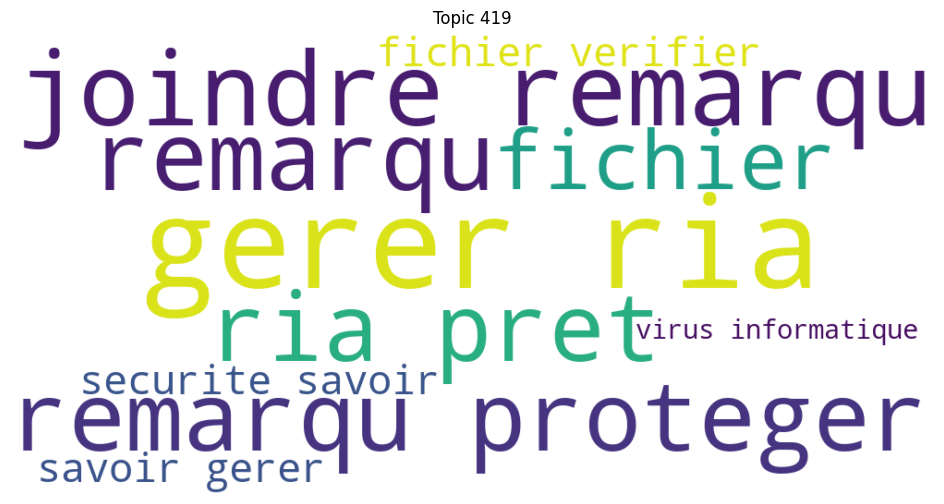

Quelques exemples de mails du topic 419

--- Exemple 1 ---
flag_client_  / RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  1672869310   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 2 ---
flag_client_  flag_nom_   /  RIA. Votre message est prêt à être envoyé avec les fichiers ou liens joints suivants :  2000571542   Remarque : pour se protéger des virus informatiques, les programmes de messagerie électronique peuvent interdire la réception de certains types de fichiers en pièce jointe. Vérifiez les paramètres de sécurité de votre messagerie électronique pour savoir comment sont gérées les pièces jointes.

--- Exemple 3 ---
flag_client_  / RIA. Votre message est prêt à être envoyé avec les f

In [33]:
# Exemples de mail
for elem in topic_summary.head(30).index.tolist()[:30]:
    print(f"------------------------------------------------------")
    print(f"        Topic identifié {elem}")
    print(f"------------------------------------------------------")
    plot_topic_wordcloud(topic_model, topic_id=elem, title=f"Topic {elem}")
    print(f"Quelques exemples de mails du topic {elem}")
    show_example_emails(df=central, topic_id=elem, class_value=1)
    print(f"------------------------------------------------------\n")

In [34]:
# Featuring
topic_counts

topics,topic_count_-1,topic_count_0,topic_count_1,topic_count_2,topic_count_3,...,topic_count_543,topic_count_544,topic_count_545,topic_count_546,topic_count_547
client_code,,,,,,,,,,,
22037,1,0,0,0,0,...,0,0,0,0,0
23318,1,0,0,0,0,...,0,0,0,0,0
25355,4,0,0,0,0,...,0,0,0,0,0
25663,2,0,0,0,0,...,0,0,0,0,0
27623,0,0,0,0,0,...,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
16201438,0,0,0,0,0,...,0,0,0,0,0
16201746,0,0,0,0,0,...,0,0,0,0,0
16201837,0,0,0,0,0,...,0,0,0,0,0


In [35]:
# Featuring
client_stats

,n_emails,n_topics_distinct,mean_topic_confidence
client_code,,,
22037,1,1,0.002711
23318,1,1,0.019084
25355,5,2,0.033773
25663,2,1,0.025826
27623,1,1,0.182677
...,...,...,...
16201438,1,1,1.000000
16201746,1,1,1.000000
16201837,1,1,0.174648


In [36]:
# Featuring
col_fill_na = topic_counts.columns.tolist()
for elem in client_stats.columns.tolist():
    col_fill_na.append(elem)

In [37]:
# Featuring
central_feature, left, right = dataframe_merge(df_portefeuille, client_stats, id_1="client_code", id_2="client_code")
central_feature = pd.concat([central_feature, left], axis=0)
central_feature.drop("_merge", axis=1, inplace=True)
central_feature, left, right = dataframe_merge(central_feature, topic_counts, id_1="client_code", id_2="client_code")
central_feature = pd.concat([central_feature, left], axis=0)
central_feature.drop("_merge", axis=1, inplace=True)
central_feature = central_feature.fillna(value=0, inplace=True)
central_feature

,client_code,target_resiliation_6mois,n_emails,n_topics_distinct,mean_topic_confidence,...,topic_count_543,topic_count_544,topic_count_545,topic_count_546,topic_count_547
0,22037,0,1.0,1.0,0.002711,...,0.0,0.0,0.0,0.0,0.0
1,23318,0,1.0,1.0,0.019084,...,0.0,0.0,0.0,0.0,0.0
2,25355,0,5.0,2.0,0.033773,...,0.0,0.0,0.0,0.0,0.0
3,25663,0,2.0,1.0,0.025826,...,0.0,0.0,0.0,0.0,0.0
4,27623,0,1.0,1.0,0.182677,...,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
132570,16204658,0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0
132572,16205008,0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0
132573,16205281,0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0
132574,16206464,0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0


In [38]:
# Définition des X de train et de test et des y de train et de test


## ML + evaluation
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold

X_train = central_feature.drop(['target_resiliation_6mois', 'client_code'], axis=1)
y_train = central_feature['target_resiliation_6mois']

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=700, max_depth=10)
rf.fit(X_train, y_train)


y_pred_train = rf.predict(X_train)
y_proba_train = rf.predict_proba(X_train)[:, 1]


roc_auc = roc_auc_score(y_true=y_train, y_score=y_proba_train)



print("=========== Rapport Random Forest (test) ===========\n")
print(f"Score AUC du modèle sur le jeu de test : {roc_auc:.4f}")
print(classification_report(y_true=y_train, y_pred=y_pred_train))
print("===================================================\n")


=========== Rapport Random Forest (test) ===========

Score AUC du modèle sur le jeu de test : 0.5830
              precision    recall  f1-score   support

           0       0.91      0.74      0.82    118126
           1       0.16      0.39      0.22     14450

    accuracy                           0.71    132576
   macro avg       0.53      0.57      0.52    132576
weighted avg       0.83      0.71      0.75    132576




In [39]:
# Infos du topic
pd.set_option('display.max_rows', 30)
topic_info = topic_model.get_topic_info()
topic_info.iloc[[t+1 for t in top_topics_class1], :].head(30)

,Topic,Count,Name,Representation,Representative_Docs
4,3,2326,3_resiliation_demande resiliation_resiliation contrat_resilier,"[resiliation, demande resiliation, resiliation contrat, resilier, report, reporter, infra, refus, resiliation infra, refus resiliation]","[demande resiliation, demande resiliation, resiliation]"
104,103,114,103_ria pret_fichier_savoir gerer_fichier verifier,"[ria pret, fichier, savoir gerer, fichier verifier, virus informatique, parametre securite, reception type, securite savoir, proteger virus, progr...",[ombline compagny ria pret fichier lien joindre remarque proteger virus informatique programme interdire reception type fichier verifier parametre...
5,4,2116,4_pedicur remboursement_facture pedicur_pedicur_remboursement prier,"[pedicur remboursement, facture pedicur, pedicur, remboursement prier, trouver facture, prier bien, prier, bien vouloir, bien, vouloir trouver]","[prier bien vouloir trouver facture pedicur m. remboursement, prier bien vouloir trouver facture pedicur m. remboursement, prier bien vouloir trou..."
125,124,103,124_joindre remarque_remarque proteger_remarque_gerer ria,"[joindre remarque, remarque proteger, remarque, gerer ria, ria pret, fichier, fichier verifier, savoir gerer, interdire reception, informatique pr...",[ria pret fichier lien joindre remarque proteger virus informatique programme interdire reception type fichier verifier parametre securite savoir ...
230,229,64,229_joindre remarqu_remarqu proteger_remarqu_fichier,"[joindre remarqu, remarqu proteger, remarqu, fichier, fichier verifier, savoir gerer, proteger virus, parametre securite, reception type, programm...",[pret fichier lien joindre remarqu proteger virus informatique programme interdire reception type fichier verifier parametre securite savoir gerer...
22,21,413,21_thermal_cure thermal_cure_cur thermal,"[thermal, cure thermal, cure, cur thermal, cur, remboursement cure, hebergement, forfait, facture cure, facture cur]","[cure thermal origine, alpti joint facture carburant cure thermal, facture acquitter cure thermal]"
117,116,106,116_annee pret_rad cours_cours annee_gerer rad,"[annee pret, rad cours, cours annee, gerer rad, rad, joindre remarqu, remarqu proteger, remarqu, cours, fichier]",[rad cours annee pret fichier lien joindre remarqu proteger virus informatique programme interdire reception type fichier verifier parametre secur...
259,258,60,258_remarque proteger_remarque_joindre remarque_fichier,"[remarque proteger, remarque, joindre remarque, fichier, savoir gerer, fichier verifier, informatique programme, interdire reception, programme in...",[pret fichier lien joindre remarque proteger virus informatique programme interdire reception type fichier verifier parametre securite savoir gere...
227,226,65,226_joindre remarque_remarque proteger_remarque_gerer ria,"[joindre remarque, remarque proteger, remarque, gerer ria, ria pret, fichier, savoir gerer, fichier verifier, securite savoir, virus informatique]",[ria pret fichier lien joindre remarque proteger virus informatique programme interdire reception type fichier verifier parametre securite savoir ...
215,214,68,214_gerer ria_joindre remarqu_remarqu proteger_remarqu,"[gerer ria, joindre remarqu, remarqu proteger, remarqu, ria pret, fichier, savoir gerer, fichier verifier, securite savoir, virus informatique]",[ria pret fichier lien joindre remarqu proteger virus informatique programme interdire reception type fichier verifier parametre securite savoir g...


In [42]:
# Exemples d'emails
show_example_emails(
    df=central,
    topic_id=3,
    class_value=1,
    n=10
)


--- Exemple 1 ---
flag_nom_   => résiliation contrat  Loi Chatel contrat  flag_client_. Vous trouverez ci-joint la résiliation loi Chatel de notre cliente flag_nom_ , contrat  flag_client_     Je vous remercie de me confirmer la résiliation du contrat ou s’il vous faut le courrier en LRAR. Vous remerciant de votre prompt  retour. flag_nom_   Expert en Protection Sociale  Perspectives Marines  3, rue des champs  64 100 flag_localisation_     Tel :  flag_phone_   Mail :  <mailto: flag_mail_   flag_mail_   Web :  < flag_url_ >  flag_url_   Link :  < flag_url_ >  flag_url_         SARL au capital de  flag_amount_ - Perspectives Marines -3, rue des champs  flag_cp_  flag_localisation_  - RCS flag_localisation_  848 534 020 Société de Courtage d’Assurance - N° Orias 19002474  ( < flag_url_ >  flag_url_ ). CAPELLA est une société de courtage en assurance de personnes agissant dans le cadre des dispositions de l’article L521-2-II1° b. du Code des Assurances, assurée en assurance de responsabi